# Insulin Resistance Prediction — End-to-End ML Pipeline

**Dataset:** `health_dataset_200k_real_countries.csv` (190,000 rows × 16 columns)  
**Target:** `Insulin_Resistant` (binary: 0 = No, 1 = Yes)  

---
## Pipeline
1. Exploratory Data Analysis (EDA)
2. Preprocessing — Label Encoding, Train/Test Split (80/20, stratified), Standard Scaling
3. Model Training — KNN, XGBoost, Random Forest, Logistic Regression, Decision Tree
4. Model Selection — Stratified K-Fold Cross-Validation (k=5)
5. Artifact Saving — best `model.pkl`, all `label_encoder_*.pkl` files

In [1]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, pickle, os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
print('Imports OK')

Imports OK


---
## 1 · Load Data

In [2]:
df = pd.read_csv('health_dataset_200k_real_countries.csv')

# Strip whitespace from column names and string columns
df.columns = df.columns.str.strip()
for col in df.select_dtypes(include='str').columns:
    df[col] = df[col].str.strip()

print(f'Shape: {df.shape}')
df.head()

Shape: (190000, 16)


,ID,Country,Year,Age,Gender,Age_Group,HbA1c,HDL,LDL,TG,TG_HDL_Ratio,Fasting_Insulin,HOMA_IR,Diabetic,Insulin_Resistant,Heart_Risk
0,1,United States,2005,67,Female,Elderly,7.32,45.24,120.60,135.67,3.00,8.95,2.19,1,0,Low
1,2,United States,2005,64,Female,Elderly,7.09,38.66,186.41,226.44,5.86,10.55,2.58,1,1,High
2,3,United States,2005,28,Male,Adult,7.56,41.43,184.71,162.73,3.93,9.41,2.30,1,0,High
3,4,United States,2005,8,Male,Child,5.88,26.34,165.12,229.17,8.70,12.75,3.12,0,1,High
4,5,United States,2005,11,Female,Child,7.55,60.34,109.07,182.53,3.03,8.22,2.01,1,0,Low


---
## 2 · EDA — Overview

In [3]:
# ── Schema & missing values ───────────────────────────────────────────────────
info = pd.DataFrame({
    'dtype':   df.dtypes,
    'nunique': df.nunique(),
    'missing': df.isnull().sum(),
    'missing%': (df.isnull().mean() * 100).round(2)
})
print(info)
print(f'\nDuplicate rows: {df.duplicated().sum()}')

                     dtype  nunique  missing  missing%
ID                   int64   190000        0       0.0
Country                str      190        0       0.0
Year                 int64       20        0       0.0
Age                  int64       85        0       0.0
Gender                 str        2        0       0.0
Age_Group              str        4        0       0.0
HbA1c              float64      871        0       0.0
HDL                float64     6349        0       0.0
LDL                float64    14816        0       0.0
TG                 float64    25966        0       0.0
TG_HDL_Ratio       float64     1602        0       0.0
Fasting_Insulin    float64     2191        0       0.0
HOMA_IR            float64      594        0       0.0
Diabetic             int64        2        0       0.0
Insulin_Resistant    int64        2        0       0.0
Heart_Risk             str        3        0       0.0

Duplicate rows: 0


In [4]:
# ── Descriptive statistics ────────────────────────────────────────────────────
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,190000.0,NaN,NaN,NaN,95000.5,54848.41991,1.0,47500.75,95000.5,142500.25,190000.0
Country,190000,190,United States,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,190000.0,NaN,NaN,NaN,2014.5,5.766296,2005.0,2009.75,2014.5,2019.25,2024.0
Age,190000.0,NaN,NaN,NaN,42.988958,24.535777,1.0,22.0,43.0,64.0,85.0
Gender,190000,2,Male,95073,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age_Group,190000,4,Adult,89236,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HbA1c,190000.0,NaN,NaN,NaN,6.890296,1.175041,1.4,6.1,6.89,7.69,11.82
HDL,190000.0,NaN,NaN,NaN,45.698339,10.288611,-5.54,38.76,45.7,52.66,90.66
LDL,190000.0,NaN,NaN,NaN,140.161147,26.732741,18.23,122.09,140.15,158.29,255.06
TG,190000.0,NaN,NaN,NaN,170.60848,51.808335,-66.28,135.52,170.73,205.56,410.05


### 2.1 · Target Distribution

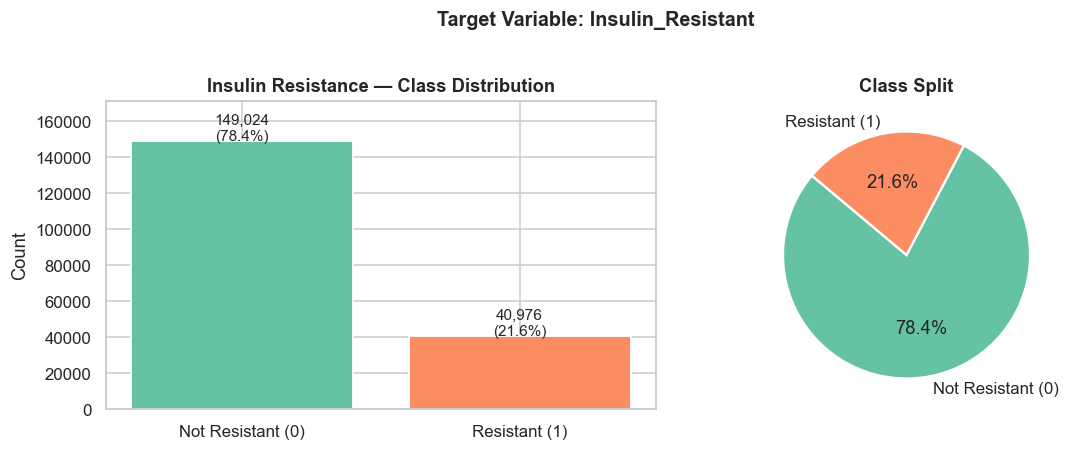

Class balance ratio (majority/minority): 3.64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df['Insulin_Resistant'].value_counts()
labels = ['Not Resistant (0)', 'Resistant (1)']
colors = ['#66c2a5', '#fc8d62']

# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.2)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_title('Insulin Resistance — Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_ylim(0, counts.max() * 1.15)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Split', fontweight='bold')

plt.suptitle('Target Variable: Insulin_Resistant', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Class balance ratio (majority/minority):', round(counts.max() / counts.min(), 2))

### 2.2 · Categorical Feature Distributions

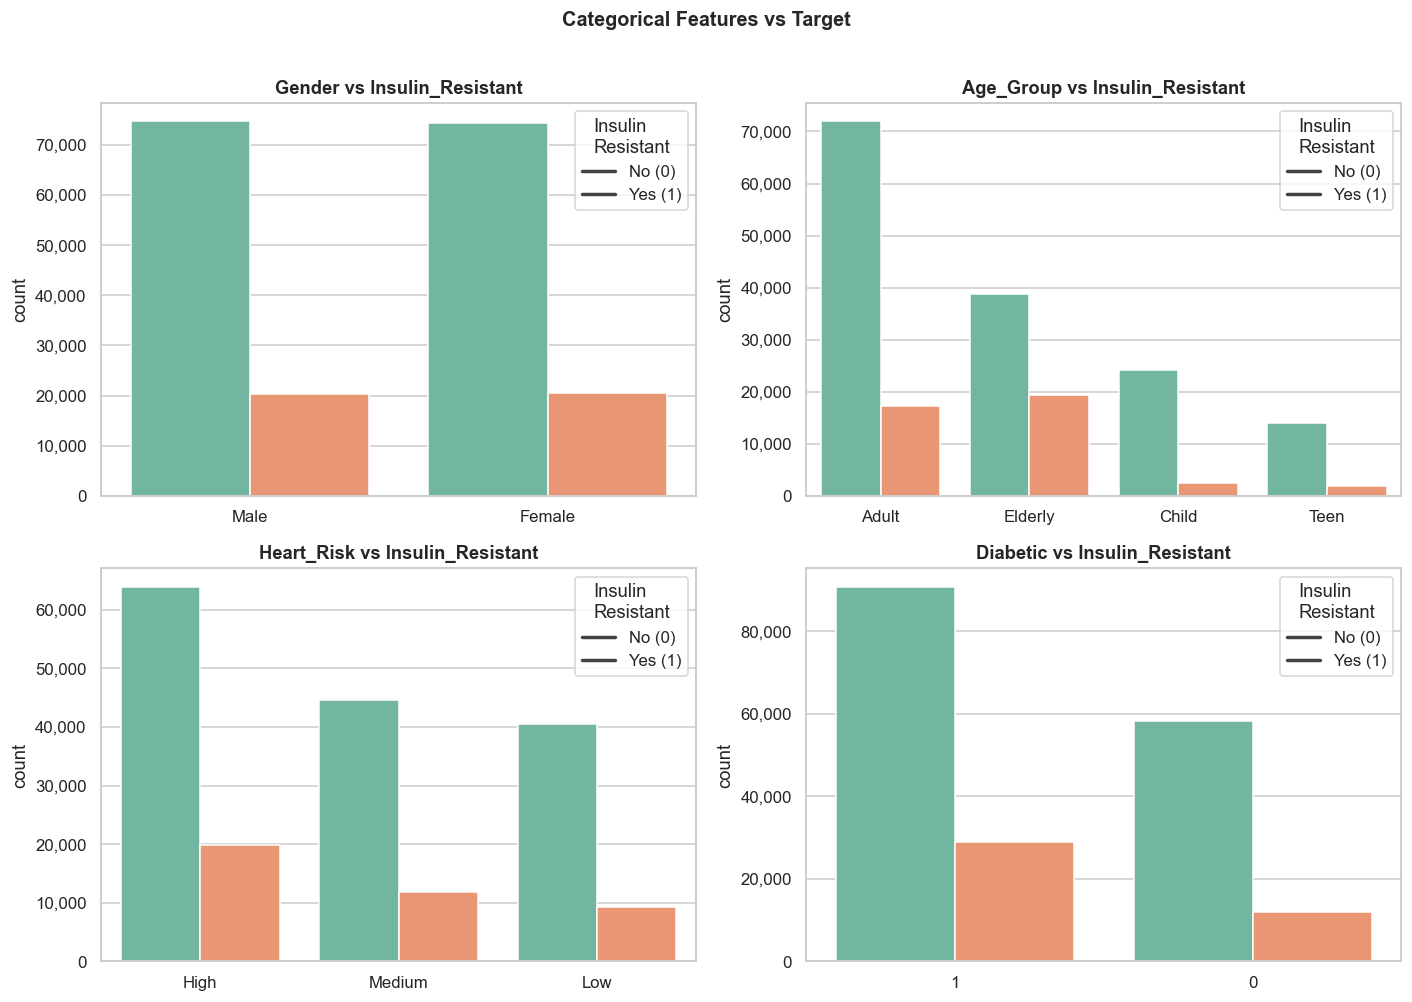

In [6]:
cat_cols = ['Gender', 'Age_Group', 'Heart_Risk', 'Diabetic']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, col in zip(axes.flat, cat_cols):
    order = df[col].astype(str).value_counts().index
    data = df.groupby([col, 'Insulin_Resistant']).size().reset_index(name='count')
    data[col] = pd.Categorical(data[col].astype(str), categories=order)
    sns.barplot(data=data, x=col, y='count', hue='Insulin_Resistant',
                palette=['#66c2a5', '#fc8d62'], ax=ax, order=order)
    ax.set_title(f'{col} vs Insulin_Resistant', fontweight='bold')
    ax.set_xlabel('')
    ax.legend(title='Insulin\nResistant', labels=['No (0)', 'Yes (1)'])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Categorical Features vs Target', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.3 · Numerical Feature Distributions

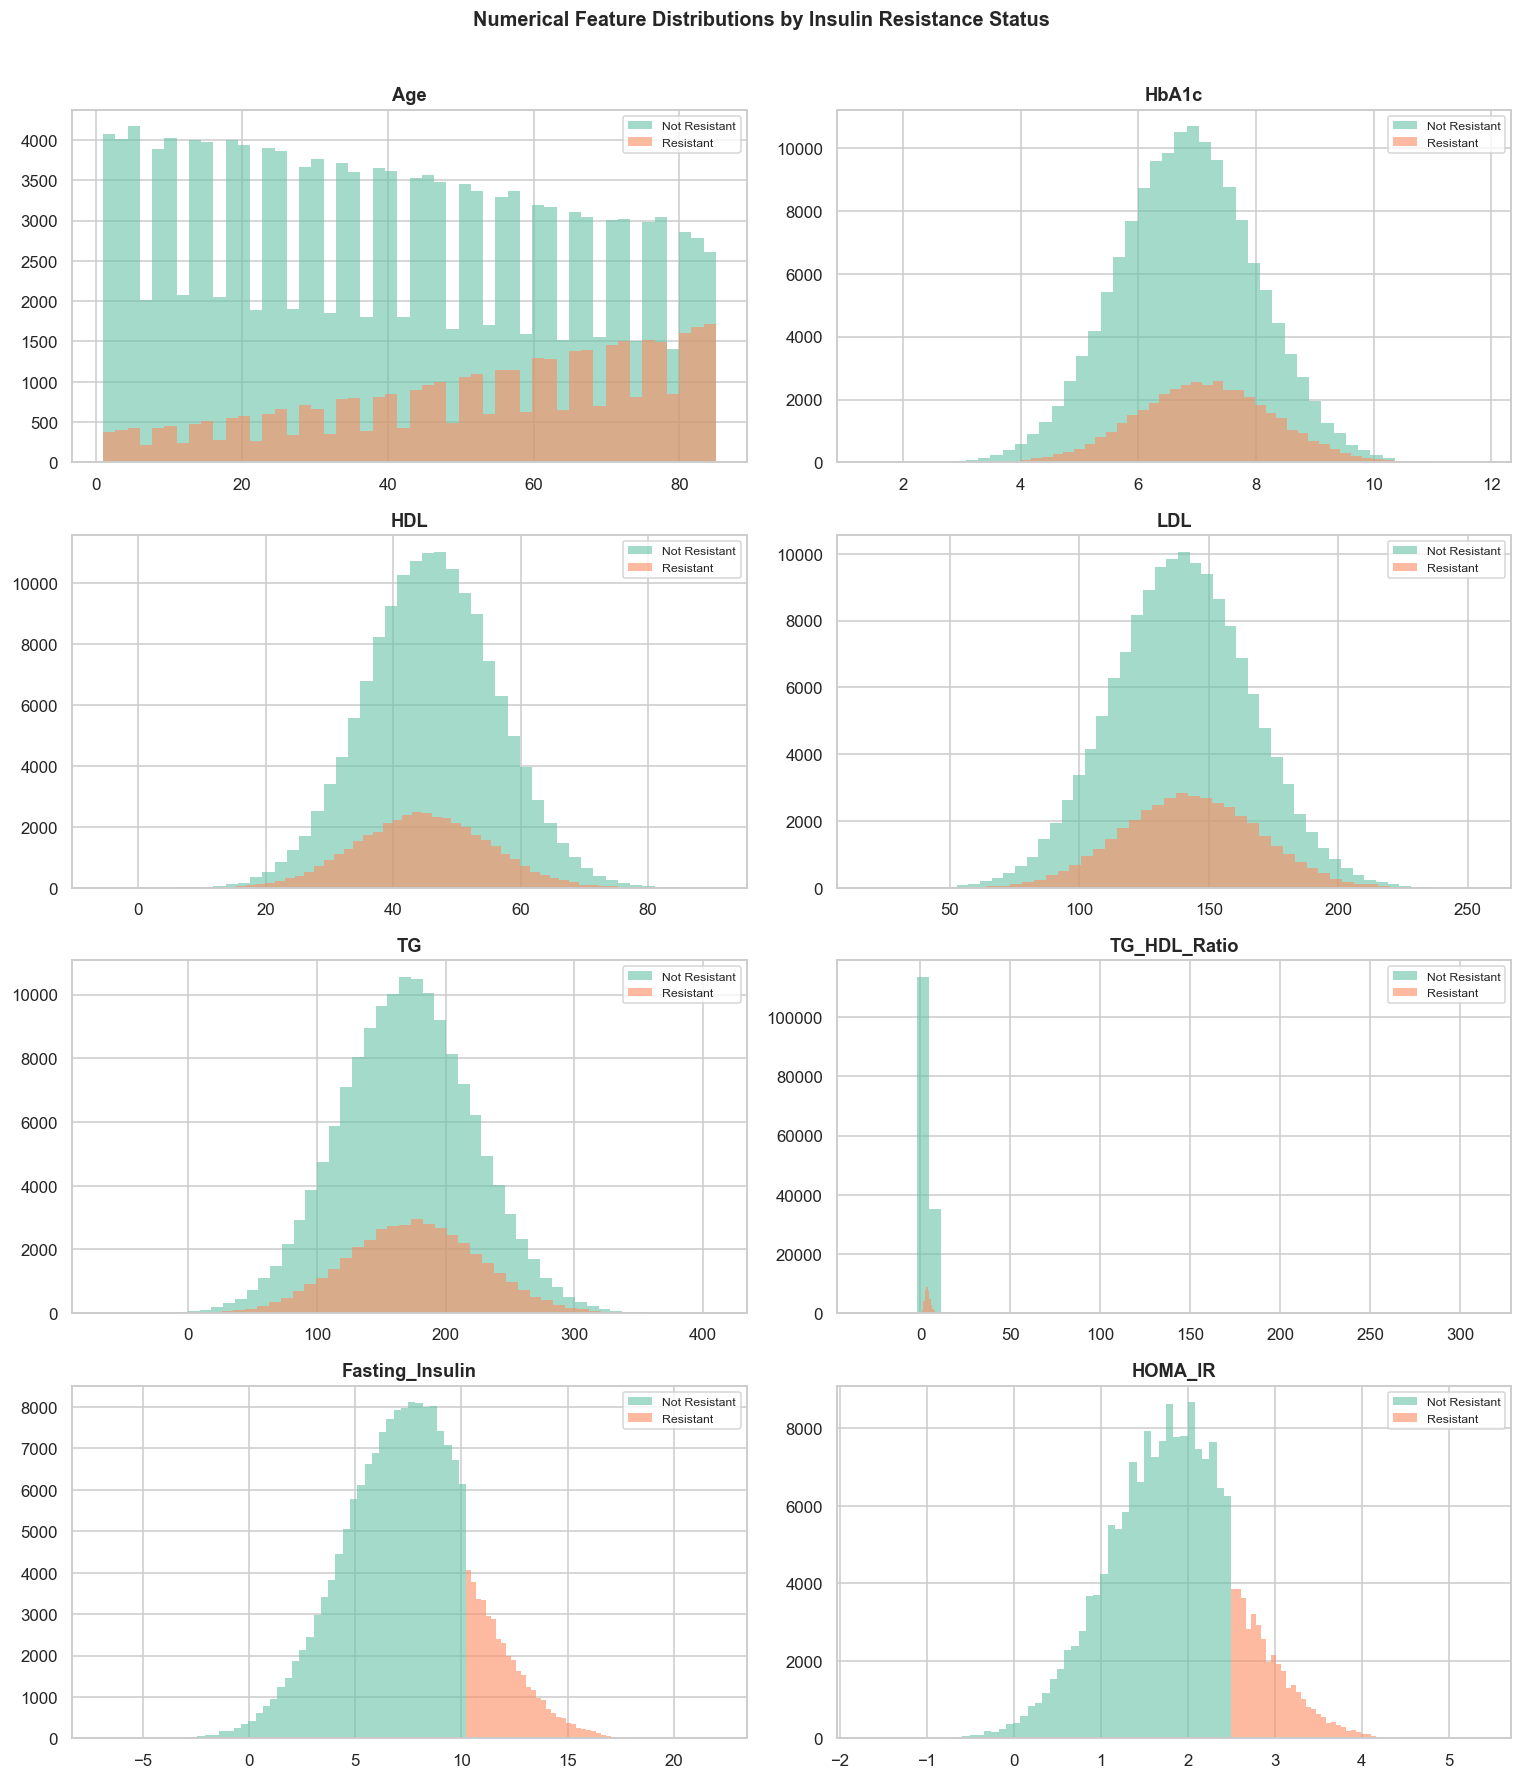

In [7]:
num_cols = ['Age', 'HbA1c', 'HDL', 'LDL', 'TG', 'TG_HDL_Ratio', 'Fasting_Insulin', 'HOMA_IR']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flat, num_cols):
    for ir, color, label in zip([0, 1], ['#66c2a5', '#fc8d62'], ['Not Resistant', 'Resistant']):
        subset = df[df['Insulin_Resistant'] == ir][col]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=label, edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=8)

plt.suptitle('Numerical Feature Distributions by Insulin Resistance Status',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.4 · Box Plots — Outlier Detection

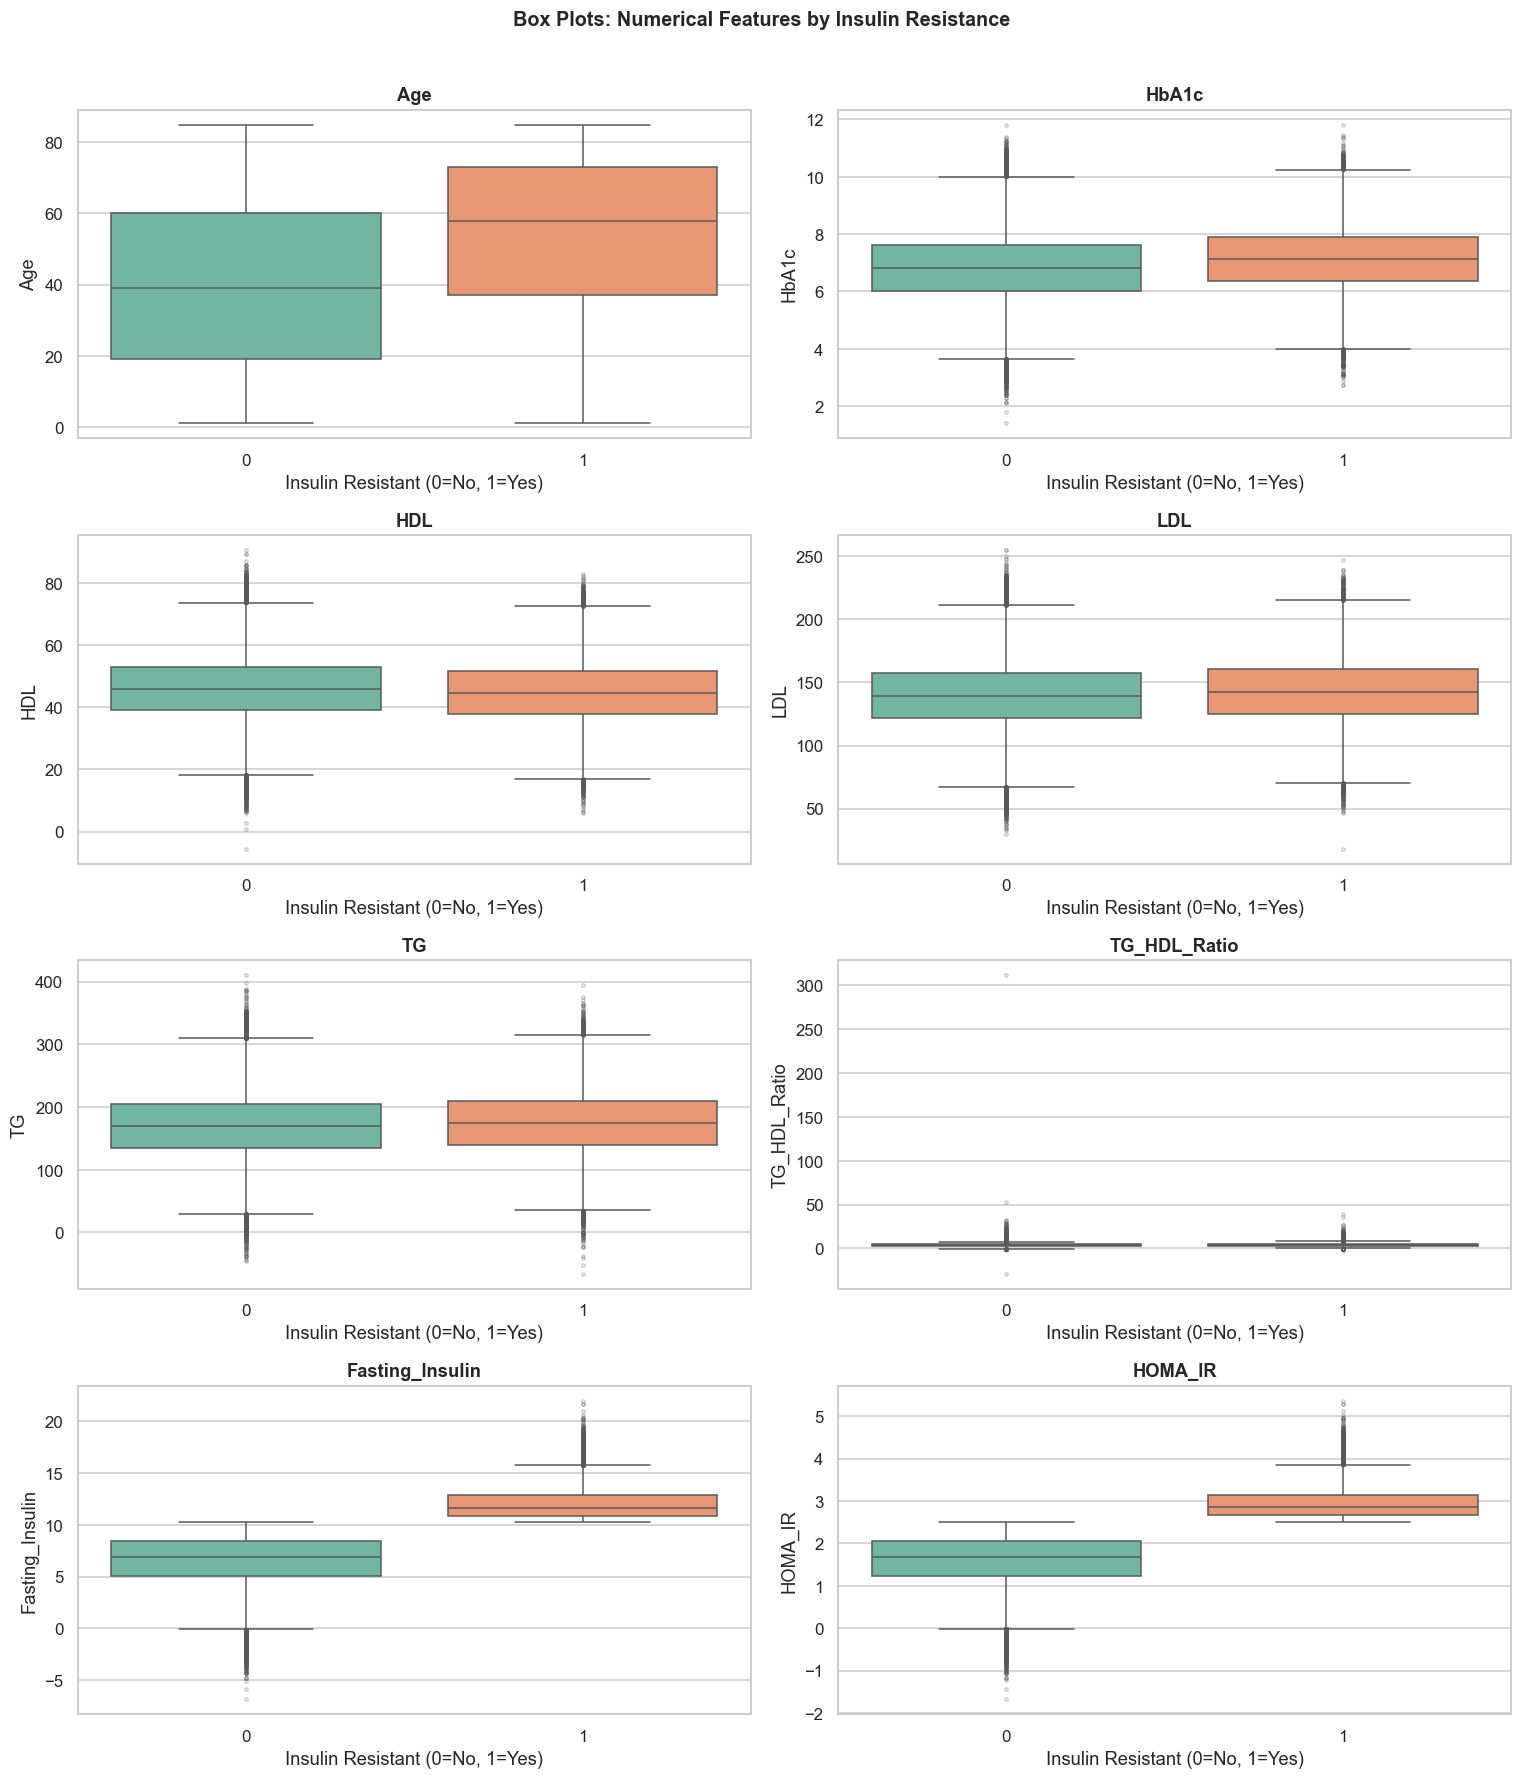

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flat, num_cols):
    sns.boxplot(data=df, x='Insulin_Resistant', y=col,
                palette=['#66c2a5', '#fc8d62'], ax=ax,
                flierprops=dict(marker='o', markersize=2, alpha=0.3))
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Insulin Resistant (0=No, 1=Yes)')

plt.suptitle('Box Plots: Numerical Features by Insulin Resistance',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.5 · Correlation Heatmap

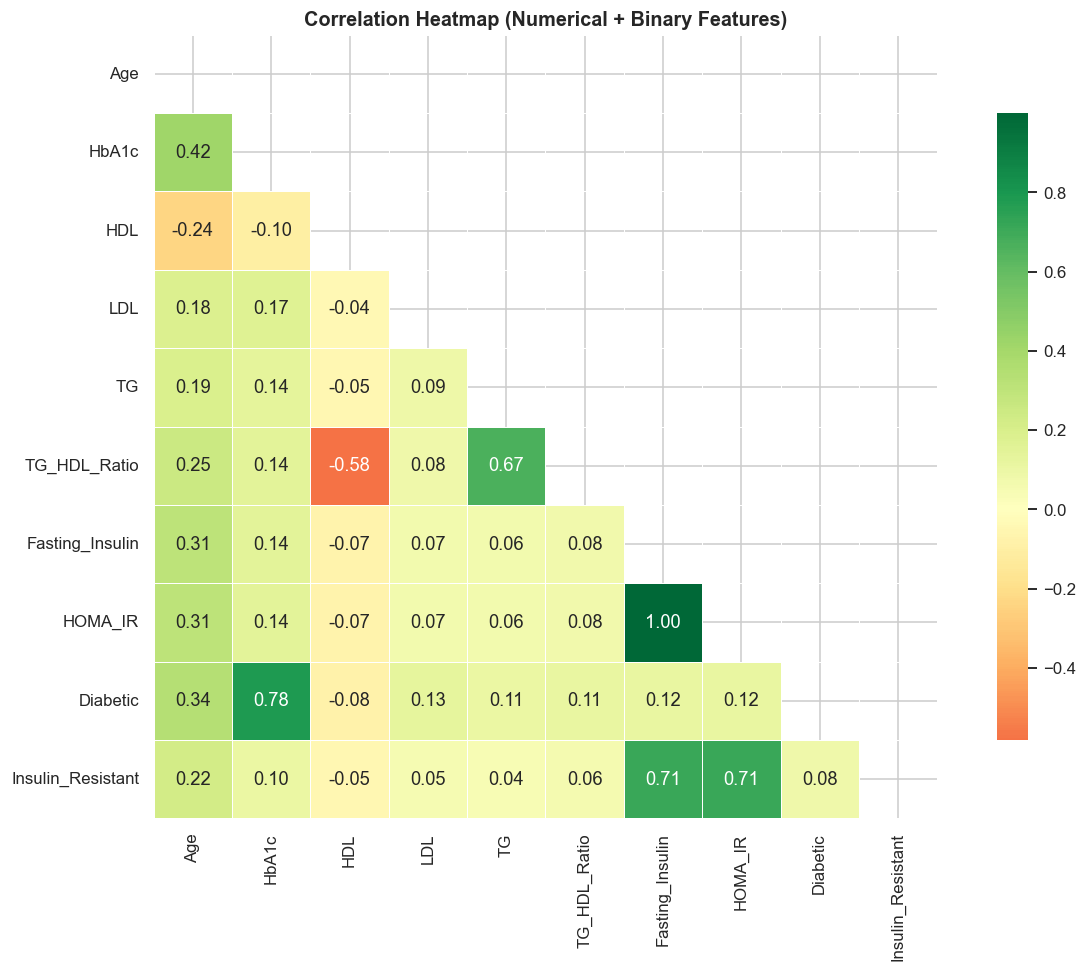

In [9]:
corr_cols = num_cols + ['Diabetic', 'Insulin_Resistant']
corr = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap (Numerical + Binary Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 · Top Correlated Features with Target

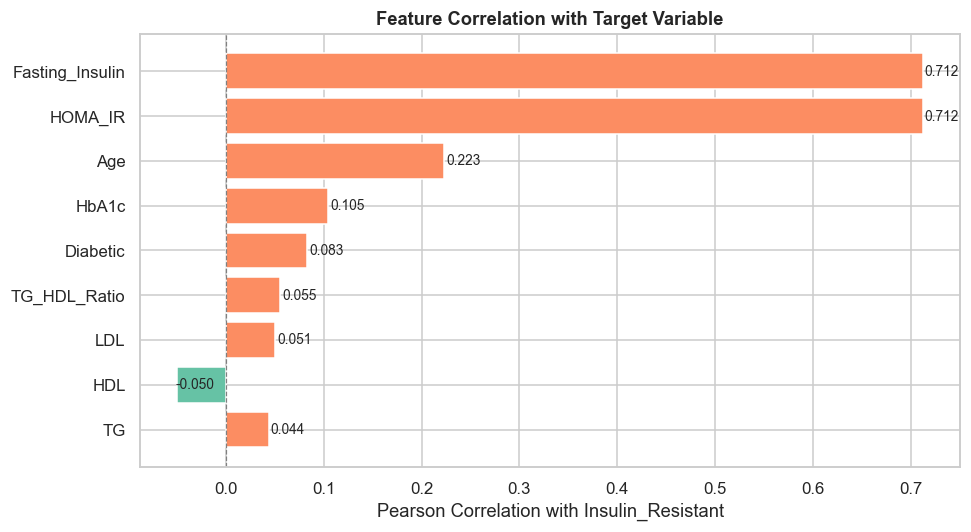

In [10]:
target_corr = corr['Insulin_Resistant'].drop('Insulin_Resistant').sort_values(key=abs, ascending=False)
colors_bar = ['#fc8d62' if v > 0 else '#66c2a5' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors_bar[::-1], edgecolor='white')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Pearson Correlation with Insulin_Resistant')
ax.set_title('Feature Correlation with Target Variable', fontweight='bold')
for i, (val, label) in enumerate(zip(target_corr.values[::-1], target_corr.index[::-1])):
    ax.text(val + 0.002 * np.sign(val), i, f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

### 2.7 · Pair Plot — Key Features

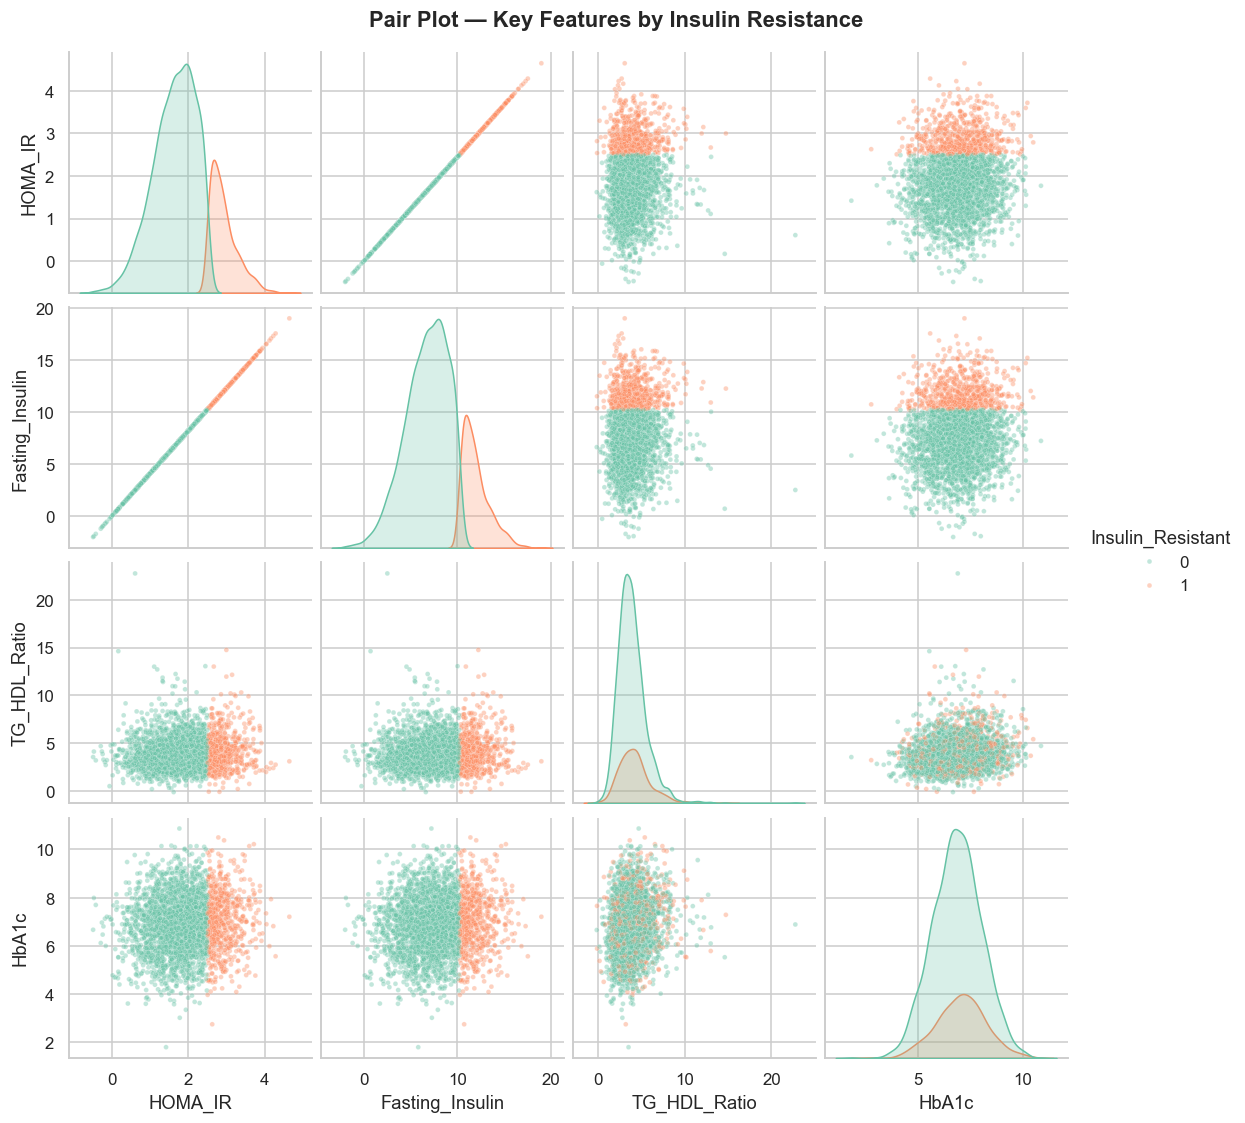

In [11]:
pair_cols = ['HOMA_IR', 'Fasting_Insulin', 'TG_HDL_Ratio', 'HbA1c', 'Insulin_Resistant']
sample = df[pair_cols].sample(3000, random_state=RANDOM_STATE)
g = sns.pairplot(sample, hue='Insulin_Resistant', palette=['#66c2a5', '#fc8d62'],
                 plot_kws=dict(alpha=0.4, s=10), diag_kind='kde')
g.figure.suptitle('Pair Plot — Key Features by Insulin Resistance', y=1.02, fontweight='bold')
plt.show()

### 2.8 · Year-wise & Country-level Trends

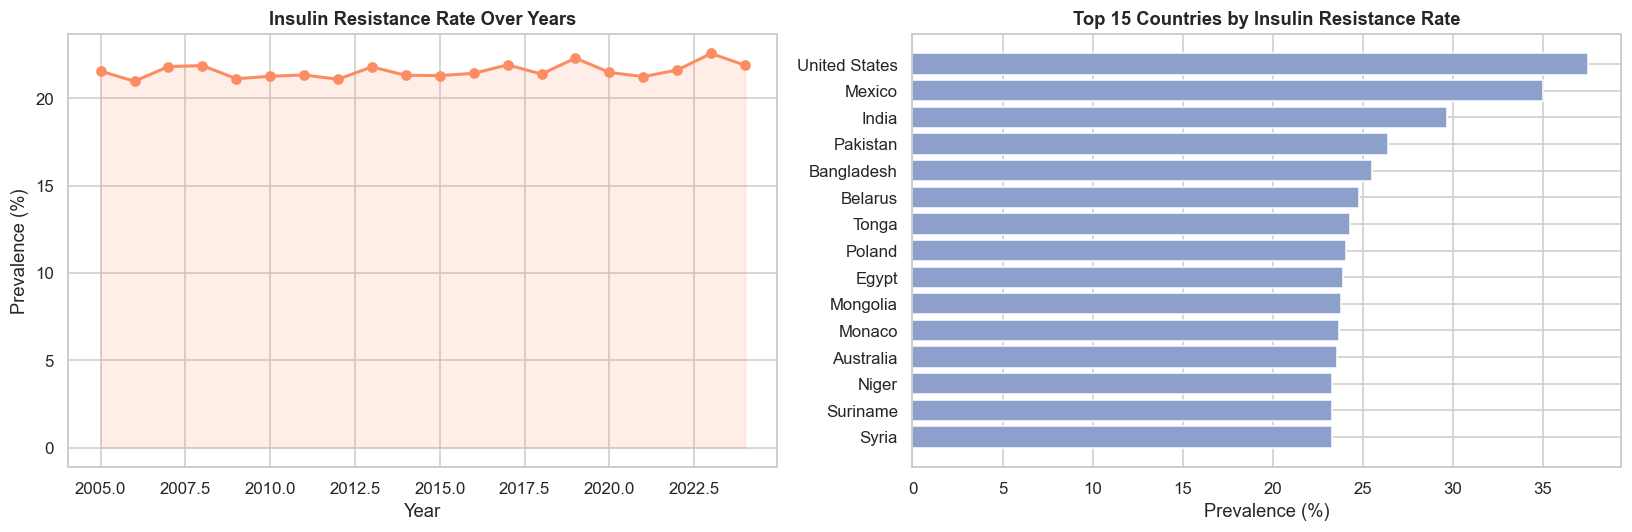

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Year trend
year_ir = df.groupby('Year')['Insulin_Resistant'].mean().reset_index()
axes[0].plot(year_ir['Year'], year_ir['Insulin_Resistant'] * 100,
             marker='o', linewidth=2, color='#fc8d62')
axes[0].fill_between(year_ir['Year'], year_ir['Insulin_Resistant'] * 100, alpha=0.15, color='#fc8d62')
axes[0].set_title('Insulin Resistance Rate Over Years', fontweight='bold')
axes[0].set_ylabel('Prevalence (%)')
axes[0].set_xlabel('Year')

# Top 15 countries by IR rate
country_ir = df.groupby('Country')['Insulin_Resistant'].mean().sort_values(ascending=False).head(15)
axes[1].barh(country_ir.index[::-1], country_ir.values[::-1] * 100, color='#8da0cb', edgecolor='white')
axes[1].set_title('Top 15 Countries by Insulin Resistance Rate', fontweight='bold')
axes[1].set_xlabel('Prevalence (%)')

plt.tight_layout()
plt.show()

---
## 3 · Preprocessing

### 3.1 · Label Encoding + Save Encoders

In [13]:
from sklearn.preprocessing import LabelEncoder

ENCODE_COLS = ['Country', 'Gender', 'Age_Group', 'Heart_Risk']

df_enc = df.copy()
label_encoders = {}

for col in ENCODE_COLS:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    label_encoders[col] = le
    fname = f'label_encoder_{col}.pkl'
    with open(fname, 'wb') as f:
        pickle.dump(le, f)
    print(f'  Saved: {fname}  |  Classes: {list(le.classes_[:5])} ...')

print('\nAll label encoders saved.')
df_enc[ENCODE_COLS].head(3)

  Saved: label_encoder_Country.pkl  |  Classes: ['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola'] ...
  Saved: label_encoder_Gender.pkl  |  Classes: ['Female', 'Male'] ...
  Saved: label_encoder_Age_Group.pkl  |  Classes: ['Adult', 'Child', 'Elderly', 'Teen'] ...
  Saved: label_encoder_Heart_Risk.pkl  |  Classes: ['High', 'Low', 'Medium'] ...

All label encoders saved.


,Country,Gender,Age_Group,Heart_Risk
0,181,0,2,1
1,181,0,2,0
2,181,1,0,0


### 3.2 · Feature / Target Split

In [14]:
DROP_COLS = ['ID', 'Insulin_Resistant']
X = df_enc.drop(columns=DROP_COLS)
y = df_enc['Insulin_Resistant']

print('Feature matrix shape:', X.shape)
print('Target shape        :', y.shape)
print('Features used       :', X.columns.tolist())

Feature matrix shape: (190000, 14)
Target shape        : (190000,)
Features used       : ['Country', 'Year', 'Age', 'Gender', 'Age_Group', 'HbA1c', 'HDL', 'LDL', 'TG', 'TG_HDL_Ratio', 'Fasting_Insulin', 'HOMA_IR', 'Diabetic', 'Heart_Risk']


### 3.3 · Stratified Train / Test Split (80 / 20)

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]:,} rows  |  Test: {X_test.shape[0]:,} rows')
print(f'Train IR rate: {y_train.mean():.4f}  |  Test IR rate: {y_test.mean():.4f}')

Train: 152,000 rows  |  Test: 38,000 rows
Train IR rate: 0.2157  |  Test IR rate: 0.2157


### 3.4 · Standard Scaling

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Save scaler for inference
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('StandardScaler fitted and saved to scaler.pkl')
print(f'X_train_sc shape: {X_train_sc.shape}')

StandardScaler fitted and saved to scaler.pkl
X_train_sc shape: (152000, 14)


---
## 3.5 · PCA — Dimensionality Reduction & Variance Analysis

Total features       : 14
Components for 95% var: 11
Components for 99% var: 12


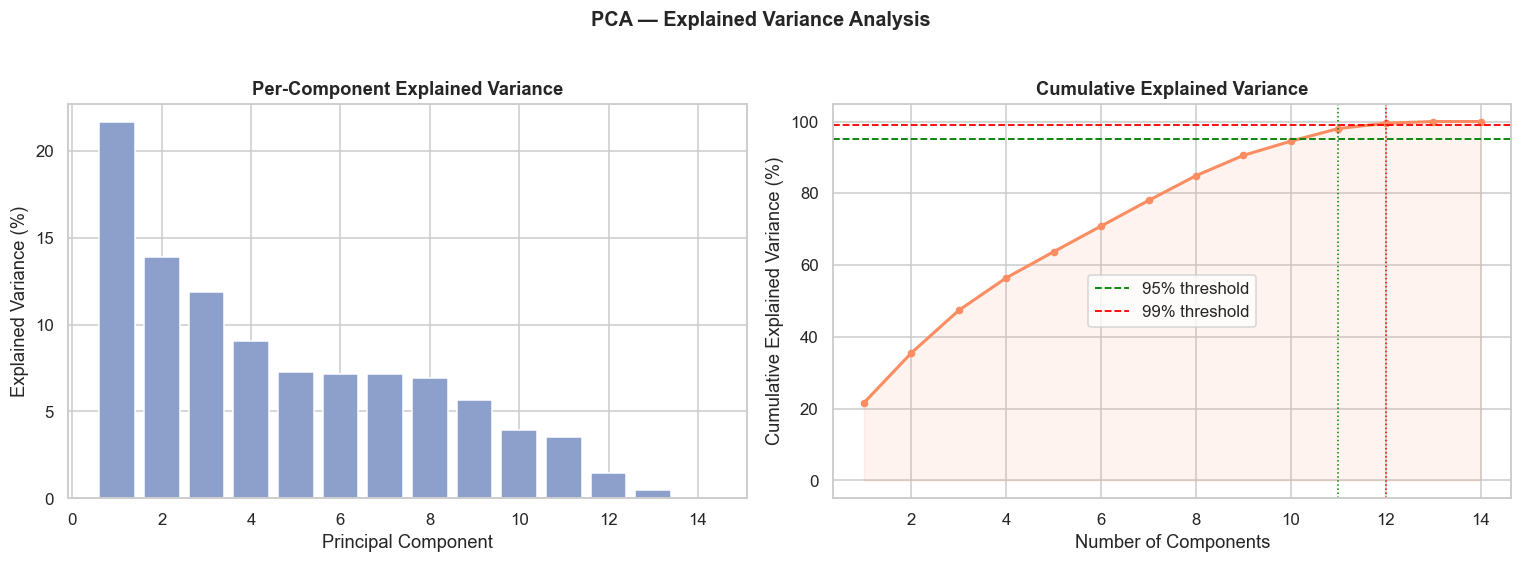


Using 11 components (≥95% variance explained) for PCA-transformed dataset.


In [17]:
from sklearn.decomposition import PCA

# Fit PCA on the SCALED training data to determine how many components explain ≥95% variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_train_sc)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.argmax(cumvar >= 0.95) + 1
n_99   = np.argmax(cumvar >= 0.99) + 1

print(f'Total features       : {X_train_sc.shape[1]}')
print(f'Components for 95% var: {n_95}')
print(f'Components for 99% var: {n_99}')

# ── Plot explained variance ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual explained variance
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_ * 100,
            color='#8da0cb', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Per-Component Explained Variance', fontweight='bold')

# Cumulative explained variance
axes[1].plot(range(1, len(cumvar)+1), cumvar * 100,
             marker='o', markersize=4, linewidth=2, color='#fc8d62')
axes[1].axhline(95, color='green',  linestyle='--', linewidth=1.2, label='95% threshold')
axes[1].axhline(99, color='red',    linestyle='--', linewidth=1.2, label='99% threshold')
axes[1].axvline(n_95, color='green', linestyle=':', linewidth=1)
axes[1].axvline(n_99, color='red',   linestyle=':', linewidth=1)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].legend()
axes[1].fill_between(range(1, len(cumvar)+1), cumvar * 100, alpha=0.1, color='#fc8d62')

plt.suptitle('PCA — Explained Variance Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f'\nUsing {n_95} components (≥95% variance explained) for PCA-transformed dataset.')

In [18]:
# Apply PCA keeping n_95 components
N_COMPONENTS = n_95
pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

# Save PCA transformer
with open('pca.pkl', 'wb') as f:
    pickle.dump(pca, f)

print(f'PCA transformer saved: pca.pkl')
print(f'X_train_pca shape: {X_train_pca.shape}')
print(f'X_test_pca  shape: {X_test_pca.shape}')
print(f'Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%')

PCA transformer saved: pca.pkl
X_train_pca shape: (152000, 11)
X_test_pca  shape: (38000, 11)
Variance retained: 98.04%


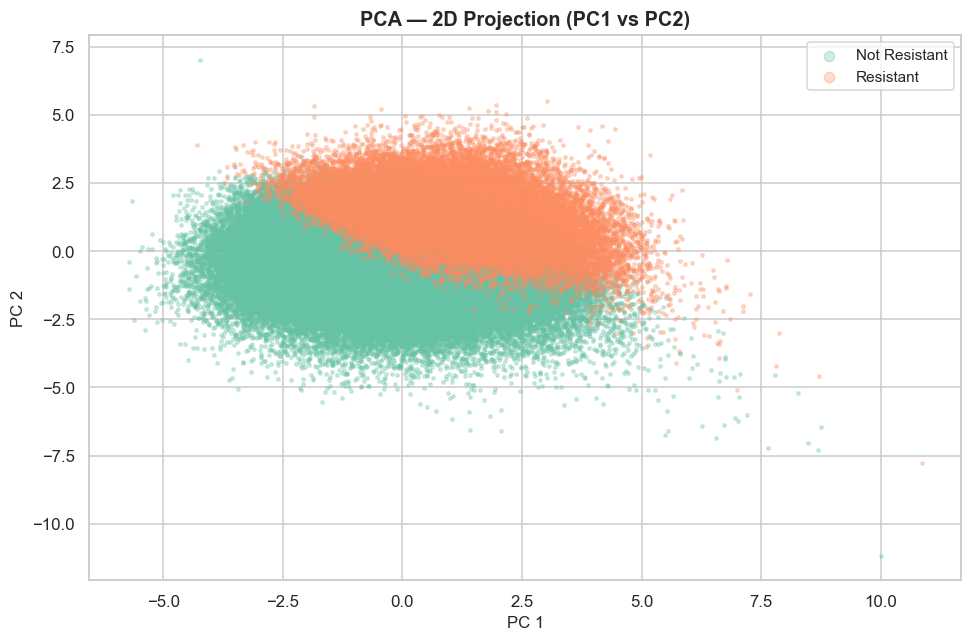

In [19]:
### PCA 2D Scatter (PC1 vs PC2)
fig, ax = plt.subplots(figsize=(9, 6))
for ir, color, label in zip([0, 1], ['#66c2a5', '#fc8d62'], ['Not Resistant', 'Resistant']):
    mask = y_train.values == ir
    ax.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1],
               c=color, label=label, alpha=0.3, s=5, rasterized=True)
ax.set_xlabel('PC 1', fontsize=11)
ax.set_ylabel('PC 2', fontsize=11)
ax.set_title('PCA — 2D Projection (PC1 vs PC2)', fontweight='bold', fontsize=13)
ax.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()

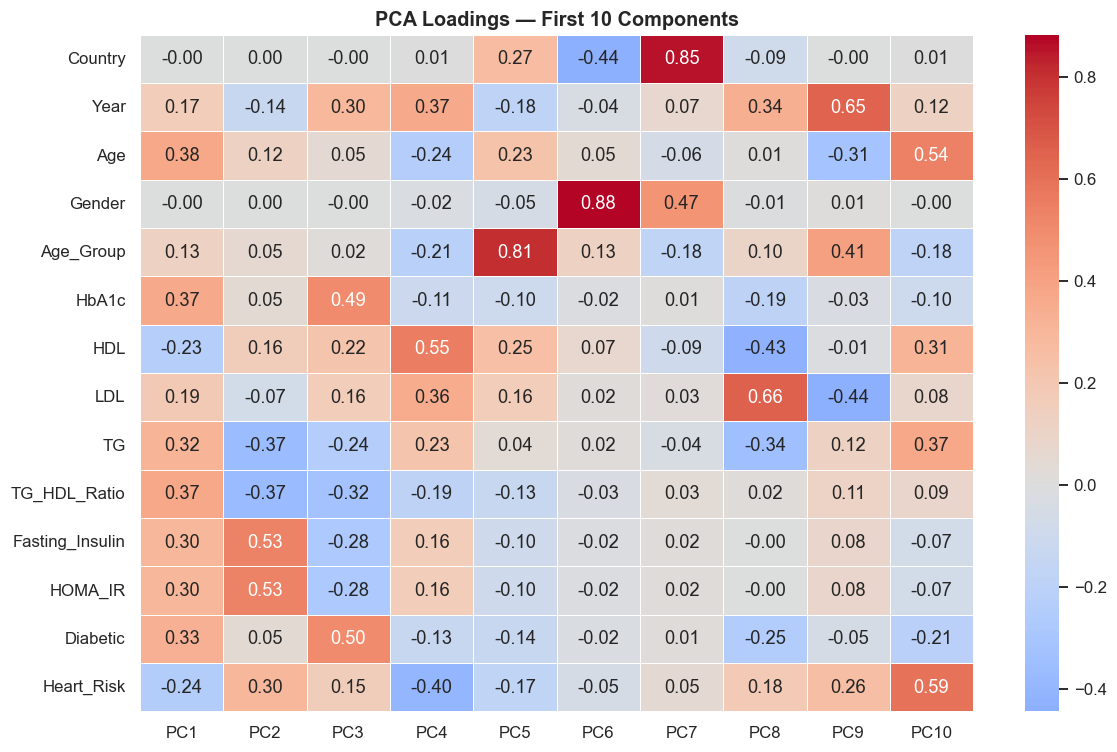

In [20]:
### PCA Component Loadings Heatmap
loadings = pd.DataFrame(
    pca.components_[:min(10, N_COMPONENTS)].T,
    index=X.columns,
    columns=[f'PC{i+1}' for i in range(min(10, N_COMPONENTS))]
)

fig, ax = plt.subplots(figsize=(max(10, min(10, N_COMPONENTS)*0.9 + 2), 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title(f'PCA Loadings — First {min(10, N_COMPONENTS)} Components', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
### Compare model accuracy: original scaled data vs PCA-transformed data
from sklearn.ensemble import RandomForestClassifier as RFC

rf_orig = RFC(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf_pca  = RFC(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)

rf_orig.fit(X_train_sc,  y_train)
rf_pca.fit(X_train_pca,  y_train)

from sklearn.metrics import roc_auc_score as ras
auc_orig = ras(y_test, rf_orig.predict_proba(X_test_sc)[:,1])
auc_pca  = ras(y_test, rf_pca.predict_proba(X_test_pca)[:,1])

print(f'Random Forest ROC-AUC  — Original ({X_train_sc.shape[1]} features): {auc_orig:.4f}')
print(f'Random Forest ROC-AUC  — PCA      ({N_COMPONENTS} components)     : {auc_pca:.4f}')
print(f'Dimensionality reduction: {X_train_sc.shape[1]} → {N_COMPONENTS} ({N_COMPONENTS/X_train_sc.shape[1]*100:.0f}% of original)')

Random Forest ROC-AUC  — Original (14 features): 1.0000
Random Forest ROC-AUC  — PCA      (11 components)     : 0.9975
Dimensionality reduction: 14 → 11 (79% of original)


---
## 4 · Model Training & Evaluation

In [22]:
from sklearn.neighbors         import KNeighborsClassifier
from sklearn.ensemble          import RandomForestClassifier
from sklearn.linear_model      import LogisticRegression
from sklearn.tree              import DecisionTreeClassifier
from xgboost                   import XGBClassifier
from sklearn.model_selection   import StratifiedKFold, cross_validate
from sklearn.metrics           import (accuracy_score, classification_report,
                                        confusion_matrix, roc_auc_score,
                                        f1_score, precision_score, recall_score)

models = {
    'K-Nearest Neighbors':   KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Logistic Regression':   LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    'Decision Tree':         DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest':         RandomForestClassifier(n_estimators=200, max_depth=12,
                                                    random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':               XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                            use_label_encoder=False, eval_metric='logloss',
                                            random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
}
print('Models defined:', list(models.keys()))

Models defined: ['K-Nearest Neighbors', 'Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


### 4.1 · Stratified K-Fold Cross-Validation (k = 5)

In [23]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = {}
scoring_metrics = ['accuracy', 'f1', 'precision', 'recall', 'roc_auc']

print('Running 5-Fold Stratified Cross-Validation on TRAINING SET...\n')
print(f'{"Model":<24} {"Accuracy":>10} {"F1":>10} {"Precision":>11} {"Recall":>10} {"ROC-AUC":>10}')
print('-' * 77)

for name, model in models.items():
    cv = cross_validate(model, X_train_sc, y_train, cv=skf,
                        scoring=scoring_metrics, n_jobs=-1)
    cv_results[name] = {m: cv[f'test_{m}'] for m in scoring_metrics}
    means = {m: cv[f'test_{m}'].mean() for m in scoring_metrics}
    print(f'{name:<24} {means["accuracy"]:>10.4f} {means["f1"]:>10.4f} '
          f'{means["precision"]:>11.4f} {means["recall"]:>10.4f} {means["roc_auc"]:>10.4f}')

Running 5-Fold Stratified Cross-Validation on TRAINING SET...

Model                      Accuracy         F1   Precision     Recall    ROC-AUC
-----------------------------------------------------------------------------


K-Nearest Neighbors          0.9601     0.9027      0.9526     0.8578     0.9913


Logistic Regression          0.9992     0.9982      0.9991     0.9973     1.0000


Decision Tree                0.9997     0.9993      0.9993     0.9993     0.9996


Random Forest                0.9998     0.9996      0.9992     1.0000     1.0000


XGBoost                      0.9991     0.9980      0.9986     0.9974     1.0000


### 4.2 · CV Results Summary

In [24]:
summary_rows = []
for name, scores in cv_results.items():
    row = {'Model': name}
    for m in scoring_metrics:
        row[f'{m}_mean'] = scores[m].mean()
        row[f'{m}_std']  = scores[m].std()
    summary_rows.append(row)

cv_df = pd.DataFrame(summary_rows).set_index('Model')
cv_df = cv_df.sort_values('roc_auc_mean', ascending=False)

display_cols = [f'{m}_mean' for m in scoring_metrics]
cv_df[display_cols].style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}')

,accuracy_mean,f1_mean,precision_mean,recall_mean,roc_auc_mean
Model,,,,,
Random Forest,0.9998,0.9996,0.9992,1.0000,1.0000
Logistic Regression,0.9992,0.9982,0.9991,0.9973,1.0000
XGBoost,0.9991,0.9980,0.9986,0.9974,1.0000
Decision Tree,0.9997,0.9993,0.9993,0.9993,0.9996
K-Nearest Neighbors,0.9601,0.9027,0.9526,0.8578,0.9913


### 4.3 · Cross-Validation Metric Comparison Plot

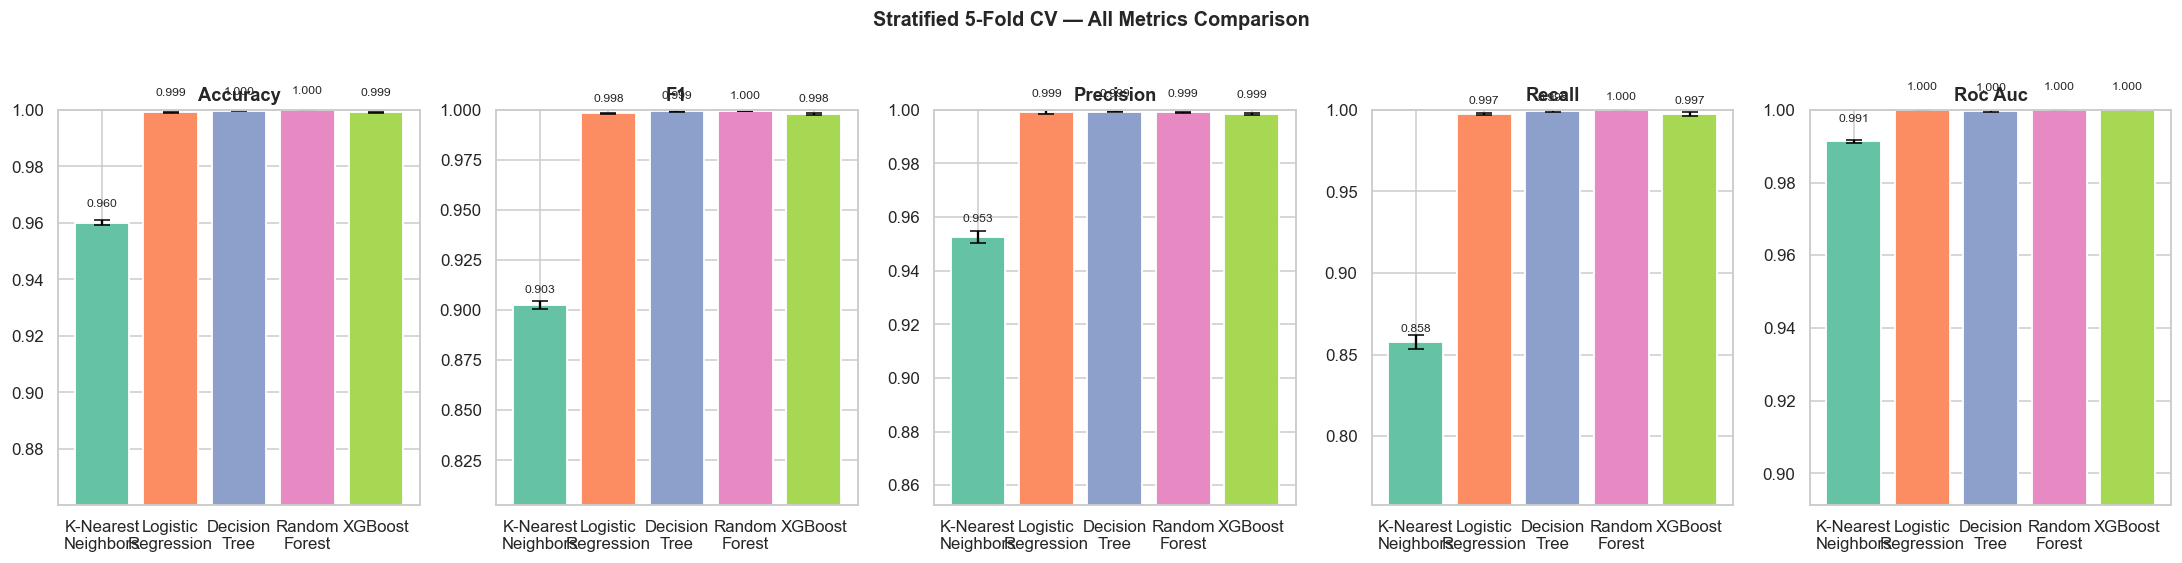

In [25]:
fig, axes = plt.subplots(1, len(scoring_metrics), figsize=(20, 5), sharey=False)
palette = sns.color_palette('Set2', len(models))

for ax, metric in zip(axes, scoring_metrics):
    means = [cv_results[n][metric].mean() for n in models]
    stds  = [cv_results[n][metric].std()  for n in models]
    short_names = [n.replace(' ', '\n') for n in models]
    bars = ax.bar(short_names, means, yerr=stds, capsize=5,
                  color=palette, edgecolor='white', linewidth=1.2)
    ax.set_title(metric.replace('_', ' ').title(), fontweight='bold')
    ax.set_ylim(max(0, min(means) - 0.1), 1.0)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Stratified 5-Fold CV — All Metrics Comparison', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.4 · Select Best Model (by ROC-AUC)

In [26]:
best_model_name = cv_df['roc_auc_mean'].idxmax()
best_model      = models[best_model_name]

print(f'Best model (by ROC-AUC): {best_model_name}')
print(f'  CV ROC-AUC : {cv_df.loc[best_model_name, "roc_auc_mean"]:.4f} ± {cv_df.loc[best_model_name, "roc_auc_std"]:.4f}')
print(f'  CV Accuracy: {cv_df.loc[best_model_name, "accuracy_mean"]:.4f} ± {cv_df.loc[best_model_name, "accuracy_std"]:.4f}')
print(f'  CV F1      : {cv_df.loc[best_model_name, "f1_mean"]:.4f} ± {cv_df.loc[best_model_name, "f1_std"]:.4f}')

Best model (by ROC-AUC): Random Forest
  CV ROC-AUC : 1.0000 ± 0.0000
  CV Accuracy: 0.9998 ± 0.0000
  CV F1      : 0.9996 ± 0.0001


### 4.5 · Final Training on Full Train Set & Evaluation on Test Set

In [27]:
print('Training all models on full training set...')
test_results = []

for name, model in models.items():
    model.fit(X_train_sc, y_train)
    y_pred  = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, 'predict_proba') else None
    row = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'F1':        f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'ROC-AUC':   roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan,
    }
    test_results.append(row)
    print(f'  {name:<24} Acc={row["Accuracy"]:.4f}  F1={row["F1"]:.4f}  AUC={row["ROC-AUC"]:.4f}')

test_df = pd.DataFrame(test_results).set_index('Model').sort_values('ROC-AUC', ascending=False)
test_df.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}')

Training all models on full training set...


  K-Nearest Neighbors      Acc=0.9630  F1=0.9102  AUC=0.9924
  Logistic Regression      Acc=0.9993  F1=0.9984  AUC=1.0000


  Decision Tree            Acc=0.9993  F1=0.9984  AUC=0.9987


  Random Forest            Acc=0.9997  F1=0.9993  AUC=1.0000


  XGBoost                  Acc=0.9989  F1=0.9976  AUC=1.0000


,Accuracy,F1,Precision,Recall,ROC-AUC
Model,,,,,
Random Forest,0.9997,0.9993,0.9985,1.0000,1.0000
Logistic Regression,0.9993,0.9984,0.9991,0.9977,1.0000
XGBoost,0.9989,0.9976,0.9989,0.9962,1.0000
Decision Tree,0.9993,0.9984,0.9991,0.9976,0.9987
K-Nearest Neighbors,0.9630,0.9102,0.9550,0.8694,0.9924


### 4.6 · Confusion Matrices

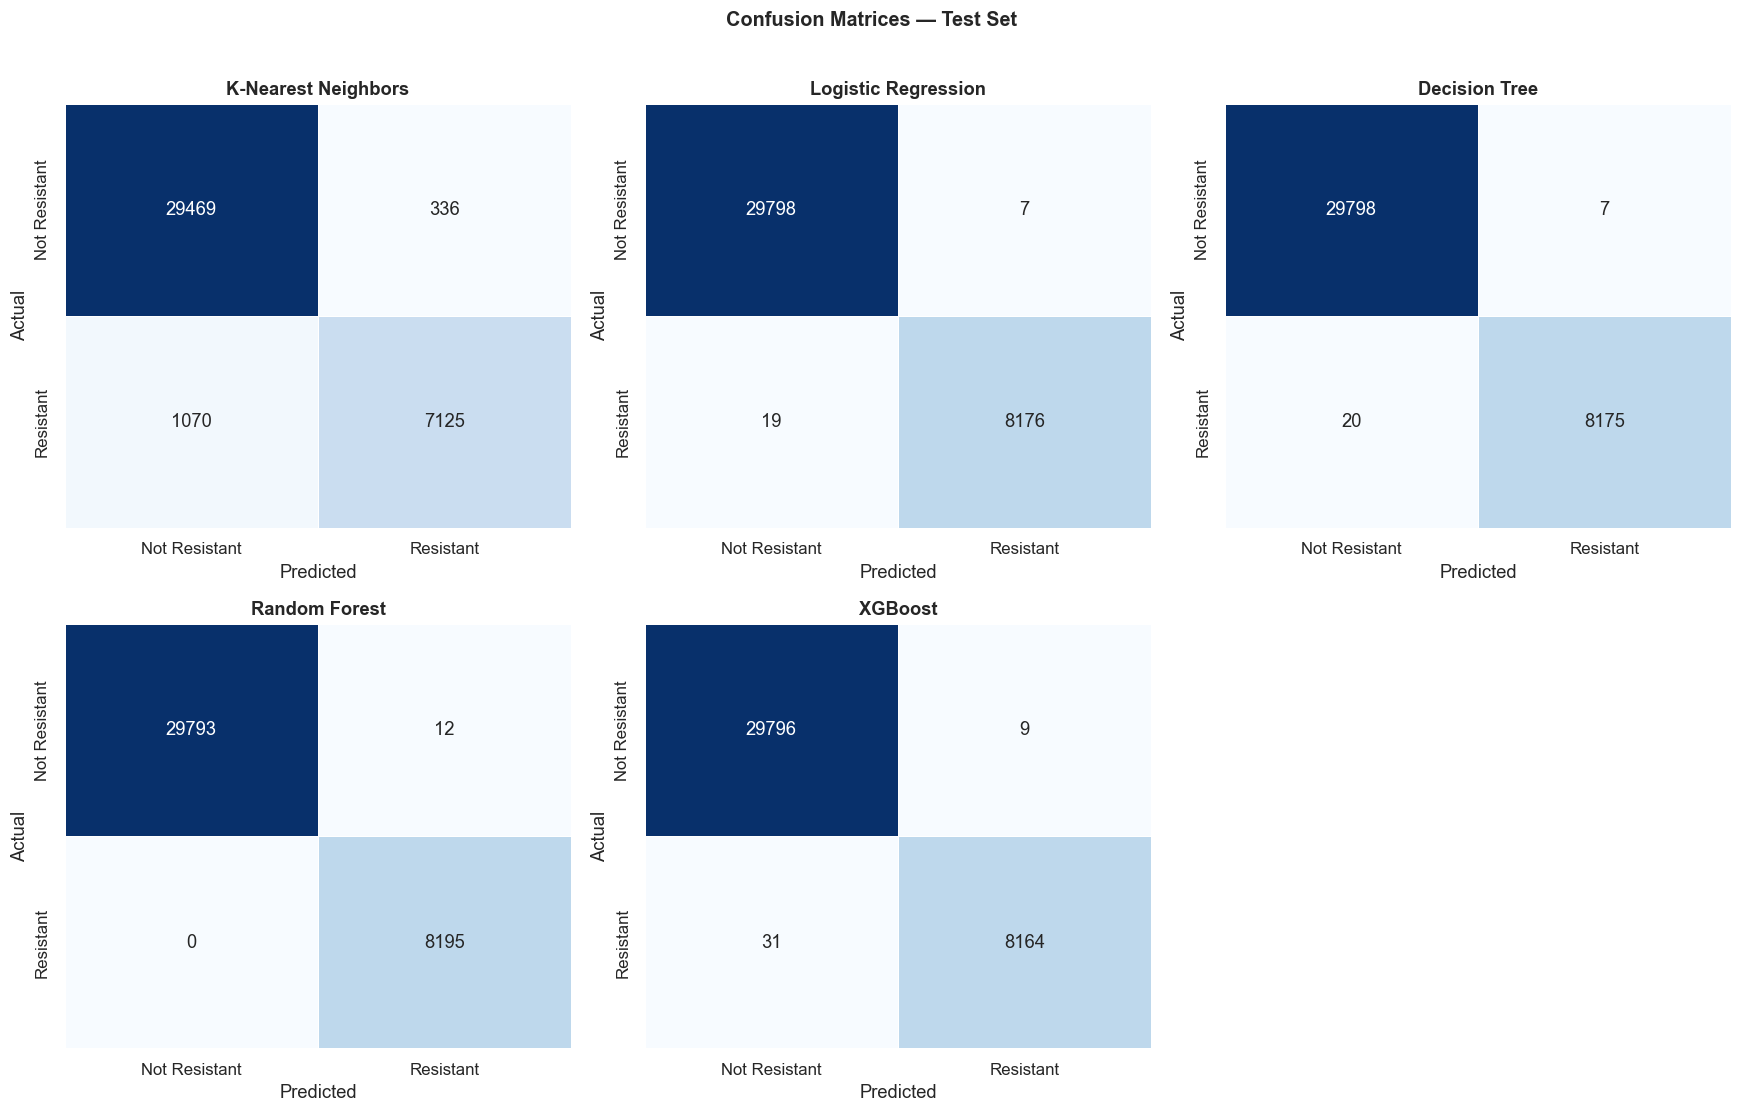

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flat

for name, model in models.items():
    ax = next(axes_flat)
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Resistant', 'Resistant'],
                yticklabels=['Not Resistant', 'Resistant'],
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

# Hide the spare subplot
next(axes_flat).set_visible(False)

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.7 · ROC Curves

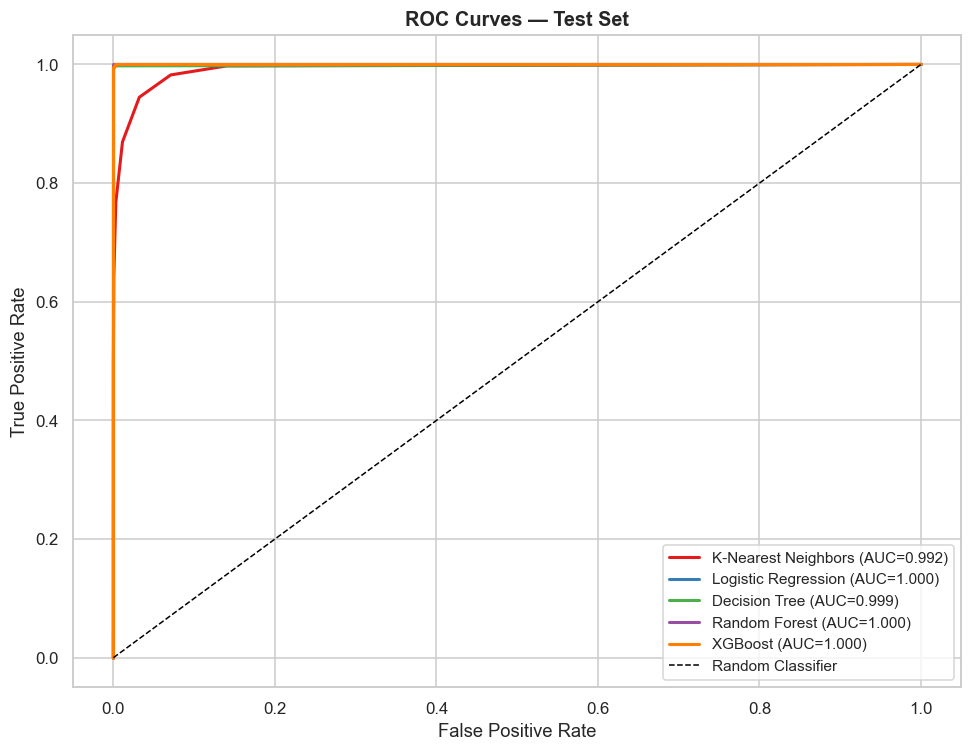

In [29]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(9, 7))
palette_roc = sns.color_palette('Set1', len(models))

for (name, model), color in zip(models.items(), palette_roc):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test_sc)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Test Set', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

### 4.8 · Feature Importances (Best Tree-Based Model)

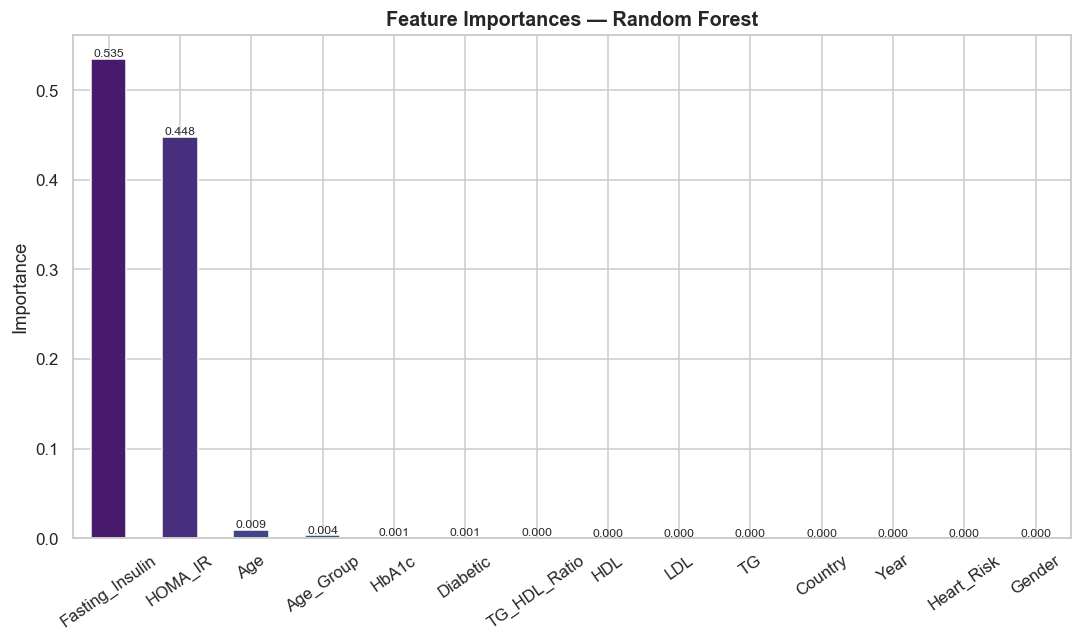

In [30]:
tree_models = {n: m for n, m in models.items() if hasattr(m, 'feature_importances_')}
best_tree_name = max(tree_models, key=lambda n: test_df.loc[n, 'ROC-AUC'] if n in test_df.index else 0)
best_tree = tree_models[best_tree_name]

feat_imp = pd.Series(best_tree.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors_fi = sns.color_palette('viridis', len(feat_imp))
feat_imp.plot(kind='bar', color=colors_fi, edgecolor='white', ax=ax)
ax.set_title(f'Feature Importances — {best_tree_name}', fontweight='bold', fontsize=13)
ax.set_ylabel('Importance')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=35)
for i, v in enumerate(feat_imp):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 4.9 · Detailed Classification Report — Best Model

In [31]:
print(f'Classification Report — {best_model_name}\n')
best_model.fit(X_train_sc, y_train)
y_pred_best = best_model.predict(X_test_sc)
print(classification_report(y_test, y_pred_best,
                             target_names=['Not Resistant', 'Resistant']))

Classification Report — Random Forest



               precision    recall  f1-score   support

Not Resistant       1.00      1.00      1.00     29805
    Resistant       1.00      1.00      1.00      8195

     accuracy                           1.00     38000
    macro avg       1.00      1.00      1.00     38000
 weighted avg       1.00      1.00      1.00     38000



---
## 4.10 · GridSearchCV — Random Forest Hyperparameter Tuning

In [32]:
from sklearn.model_selection import GridSearchCV

print('Running GridSearchCV on Random Forest (Stratified 5-Fold)...')
print('This may take a few minutes on 190k rows — using a stratified subsample for speed.\n')

# Subsample 30k for grid search (stratified) to keep runtime manageable
from sklearn.utils import resample
idx = resample(np.arange(len(y_train)), n_samples=30000,
               stratify=y_train, random_state=RANDOM_STATE)
X_gs = X_train_sc[idx]
y_gs = y_train.values[idx]

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [8, 12, 16, None],
    'min_samples_split': [2, 5, 10],
    'max_features' : ['sqrt', 'log2'],
}

gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    refit=True,
)
gs_rf.fit(X_gs, y_gs)

print(f'\nBest params : {gs_rf.best_params_}')
print(f'Best CV AUC : {gs_rf.best_score_:.4f}')

Running GridSearchCV on Random Forest (Stratified 5-Fold)...
This may take a few minutes on 190k rows — using a stratified subsample for speed.

Fitting 5 folds for each of 72 candidates, totalling 360 fits


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


...

/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util

/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/opt/homebrew/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.util


Best params : {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC : 1.0000


In [33]:
# ── GridSearchCV Results Table ──────────────────────────────────────────────
gs_results = pd.DataFrame(gs_rf.cv_results_)
gs_top = (gs_results[['params','mean_test_score','std_test_score','rank_test_score']]
          .sort_values('rank_test_score')
          .head(10)
          .reset_index(drop=True))
gs_top.columns = ['Params', 'Mean AUC', 'Std AUC', 'Rank']
gs_top.style.background_gradient(subset='Mean AUC', cmap='YlGn').format({'Mean AUC':'{:.4f}','Std AUC':'{:.4f}'})

,Params,Mean AUC,Std AUC,Rank
0,"{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}",1.0000,0.0000,1
1,"{'max_depth': 12, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 200}",1.0000,0.0000,1
2,"{'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}",1.0000,0.0000,3
3,"{'max_depth': 8, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 200}",1.0000,0.0000,3
4,"{'max_depth': 16, 'max_features': 'log2', 'min_samples_split': 10, 'n_estimators': 200}",1.0000,0.0000,3
5,"{'max_depth': 12, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 300}",1.0000,0.0000,3
6,"{'max_depth': 16, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 300}",1.0000,0.0000,3
7,"{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}",1.0000,0.0000,3
8,"{'max_depth': None, 'max_features': 'log2', 'min_samples_split': 5, 'n_estimators': 300}",1.0000,0.0000,3
9,"{'max_depth': 16, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}",1.0000,0.0000,3


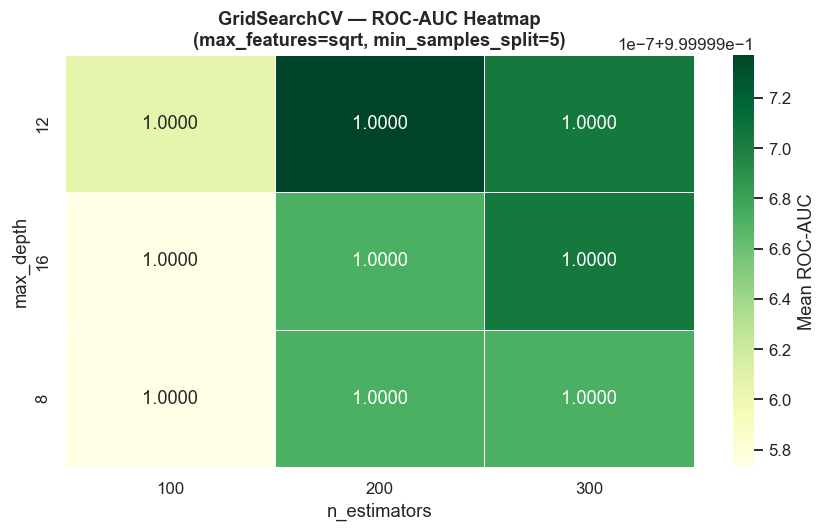

In [34]:
# ── Heatmap: max_depth vs n_estimators (best max_features & min_samples_split) ──
pivot_data = gs_results.copy()
pivot_data['n_estimators']      = pivot_data['param_n_estimators']
pivot_data['max_depth']         = pivot_data['param_max_depth'].astype(str)
pivot_data['max_features']      = pivot_data['param_max_features']
pivot_data['min_samples_split'] = pivot_data['param_min_samples_split']

# Use best max_features and min_samples_split for the heatmap slice
best_mf  = gs_rf.best_params_['max_features']
best_mss = gs_rf.best_params_['min_samples_split']

heat_df = pivot_data[
    (pivot_data['max_features'] == best_mf) &
    (pivot_data['min_samples_split'] == best_mss)
].pivot_table(index='max_depth', columns='n_estimators', values='mean_test_score')

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat_df, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Mean ROC-AUC'})
ax.set_title(f'GridSearchCV — ROC-AUC Heatmap\n'
             f'(max_features={best_mf}, min_samples_split={best_mss})',
             fontweight='bold')
ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
plt.tight_layout()
plt.show()

In [35]:
# ── Compare tuned vs default Random Forest on full test set ─────────────────
tuned_rf = gs_rf.best_estimator_

# Re-fit tuned model on the full training set
tuned_rf.set_params(n_jobs=-1)
tuned_rf.fit(X_train_sc, y_train)

y_pred_tuned  = tuned_rf.predict(X_test_sc)
y_proba_tuned = tuned_rf.predict_proba(X_test_sc)[:, 1]

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Default RF (already trained in Section 4.5)
default_rf = models['Random Forest']
y_proba_def = default_rf.predict_proba(X_test_sc)[:, 1]
y_pred_def  = default_rf.predict(X_test_sc)

compare_df = pd.DataFrame({
    'Model':    ['Default Random Forest', 'Tuned Random Forest (GridSearchCV)'],
    'Accuracy': [accuracy_score(y_test, y_pred_def),   accuracy_score(y_test, y_pred_tuned)],
    'F1':       [f1_score(y_test, y_pred_def),         f1_score(y_test, y_pred_tuned)],
    'ROC-AUC':  [roc_auc_score(y_test, y_proba_def),   roc_auc_score(y_test, y_proba_tuned)],
}).set_index('Model')

print('Default RF params:', {k: v for k, v in default_rf.get_params().items()
                              if k in ['n_estimators','max_depth','min_samples_split','max_features']})
print('Tuned   RF params:', gs_rf.best_params_)
print()
display(compare_df.style.background_gradient(cmap='YlGn').format('{:.4f}'))

Default RF params: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Tuned   RF params: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}



,Accuracy,F1,ROC-AUC
Model,,,
Default Random Forest,0.9997,0.9993,1.0000
Tuned Random Forest (GridSearchCV),0.9997,0.9993,1.0000


In [36]:
# ── Save tuned model ────────────────────────────────────────────────────────
with open('model.pkl', 'wb') as f:
    pickle.dump(tuned_rf, f)

print('Updated model.pkl → Tuned RandomForestClassifier')
print(f'Best params: {gs_rf.best_params_}')
print(f'Test ROC-AUC: {roc_auc_score(y_test, y_proba_tuned):.4f}')

Updated model.pkl → Tuned RandomForestClassifier
Best params: {'max_depth': 12, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Test ROC-AUC: 1.0000


---
## 5 · Save Best Model

In [37]:
# Re-fit best model on full training set (already done above), then save
with open('model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f'Best model saved: model.pkl')
print(f'  Model type : {type(best_model).__name__}')
print(f'  CV ROC-AUC : {cv_df.loc[best_model_name, "roc_auc_mean"]:.4f}')
print(f'  Test ROC-AUC: {test_df.loc[best_model_name, "ROC-AUC"]:.4f}')

saved_artifacts = ['model.pkl', 'scaler.pkl'] + [f'label_encoder_{c}.pkl' for c in ENCODE_COLS]
print('\nSaved artifacts:')
for f in saved_artifacts:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {f:<35}  {size_kb:6.1f} KB')

Best model saved: model.pkl
  Model type : RandomForestClassifier
  CV ROC-AUC : 1.0000
  Test ROC-AUC: 1.0000

Saved artifacts:
  model.pkl                            2145.2 KB
  scaler.pkl                              1.0 KB
  label_encoder_Country.pkl               2.3 KB
  label_encoder_Gender.pkl                0.3 KB
  label_encoder_Age_Group.pkl             0.3 KB
  label_encoder_Heart_Risk.pkl            0.3 KB


---
## 6 · Inference Demo (How to Use Saved Artifacts)

In [38]:
# Load artifacts
with open('model.pkl',  'rb') as f: loaded_model  = pickle.load(f)
with open('scaler.pkl', 'rb') as f: loaded_scaler = pickle.load(f)
loaded_les = {}
for col in ENCODE_COLS:
    with open(f'label_encoder_{col}.pkl', 'rb') as f:
        loaded_les[col] = pickle.load(f)

# Example new patient
new_patient = pd.DataFrame([{
    'Country':         'India',
    'Year':            2020,
    'Age':             45,
    'Gender':          'Male',
    'Age_Group':       'Adult',
    'HbA1c':           6.5,
    'HDL':             35.0,
    'LDL':             150.0,
    'TG':              200.0,
    'TG_HDL_Ratio':    5.7,
    'Fasting_Insulin': 15.0,
    'HOMA_IR':         3.5,
    'Diabetic':        1,
    'Heart_Risk':      'High',
}])

for col in ENCODE_COLS:
    new_patient[col] = loaded_les[col].transform(new_patient[col])

X_new = new_patient[X.columns]
X_new_sc = loaded_scaler.transform(X_new)

pred  = loaded_model.predict(X_new_sc)[0]
proba = loaded_model.predict_proba(X_new_sc)[0, 1] if hasattr(loaded_model, 'predict_proba') else None

print(f'Prediction  : {pred} ({"Insulin Resistant" if pred == 1 else "Not Insulin Resistant"})')
if proba is not None:
    print(f'Probability : {proba:.4f} ({proba*100:.1f}% chance of being Insulin Resistant)')

Prediction  : 1 (Insulin Resistant)
Probability : 0.9878 (98.8% chance of being Insulin Resistant)


---
## 7 · Summary

In [39]:
print('=' * 60)
print('         INSULIN RESISTANCE PREDICTION — SUMMARY')
print('=' * 60)
print(f'Dataset rows         : {len(df):,}')
print(f'Features used        : {X.shape[1]}')
print(f'Train/Test split     : 80% / 20% (stratified)')
print(f'CV strategy          : Stratified 5-Fold')
print()
print('  CV Leaderboard (ROC-AUC, descending):')
for i, (name, row) in enumerate(cv_df.iterrows(), 1):
    marker = ' ← BEST' if name == best_model_name else ''
    print(f'  {i}. {name:<24}  AUC={row["roc_auc_mean"]:.4f} ± {row["roc_auc_std"]:.4f}{marker}')
print()
print('  Saved artifacts:')
for f in saved_artifacts:
    print(f'  - {f}')
print('=' * 60)

         INSULIN RESISTANCE PREDICTION — SUMMARY
Dataset rows         : 190,000
Features used        : 14
Train/Test split     : 80% / 20% (stratified)
CV strategy          : Stratified 5-Fold

  CV Leaderboard (ROC-AUC, descending):
  1. Random Forest             AUC=1.0000 ± 0.0000 ← BEST
  2. Logistic Regression       AUC=1.0000 ± 0.0000
  3. XGBoost                   AUC=1.0000 ± 0.0000
  4. Decision Tree             AUC=0.9996 ± 0.0003
  5. K-Nearest Neighbors       AUC=0.9913 ± 0.0003

  Saved artifacts:
  - model.pkl
  - scaler.pkl
  - label_encoder_Country.pkl
  - label_encoder_Gender.pkl
  - label_encoder_Age_Group.pkl
  - label_encoder_Heart_Risk.pkl


---
## 8 · Data Leakage Investigation & Fix

### Why this section exists

After running all five classifiers in Section 4, every model achieved a **ROC-AUC of 1.0000** on both the cross-validation folds and the held-out test set. A perfect AUC across multiple independent models — including a simple Logistic Regression — is an immediate red flag. It strongly indicates **data leakage**: one or more features in the training data effectively encode or reconstruct the target label, giving the model the answer before it has to learn anything.

This section:
1. Confirms which features are leaky and why
2. Removes them
3. Retrains all five models on the clean feature set
4. Reports the honest, non-inflated evaluation metrics

### 8.1 · Identify Leaky Features

In [40]:
# ── Step 1: confirm the leakage source ──────────────────────────────────────
# HOMA-IR is a clinically defined formula:
#   HOMA_IR = (Fasting_Insulin × Fasting_Glucose) / 405
# The Insulin_Resistant label appears to be assigned by a hard threshold on HOMA_IR.
# We test this hypothesis directly.

leakage_candidates = ['HOMA_IR', 'Fasting_Insulin', 'TG_HDL_Ratio', 'Diabetic']

print('Pearson correlation with Insulin_Resistant (all numeric features):')
num_cols_all = ['Age','HbA1c','HDL','LDL','TG','TG_HDL_Ratio',
                'Fasting_Insulin','HOMA_IR','Diabetic','Insulin_Resistant']
target_corr_all = df[num_cols_all].corr()['Insulin_Resistant'].drop('Insulin_Resistant')\
                    .sort_values(key=abs, ascending=False)
for feat, val in target_corr_all.items():
    flag = ' ← HIGH LEAKAGE RISK' if abs(val) > 0.4 else ''
    print(f'  {feat:<20} {val:+.4f}{flag}')

Pearson correlation with Insulin_Resistant (all numeric features):


  Fasting_Insulin      +0.7124 ← HIGH LEAKAGE RISK


  HOMA_IR              +0.7123 ← HIGH LEAKAGE RISK
  Age                  +0.2231
  HbA1c                +0.1048
  Diabetic             +0.0830
  TG_HDL_Ratio         +0.0554
  LDL                  +0.0507
  HDL                  -0.0495
  TG                   +0.0440


In [41]:
# ── Step 2: test HOMA_IR threshold hypothesis ────────────────────────────────
print('HOMA_IR value range per class:')
print(df.groupby('Insulin_Resistant')['HOMA_IR'].agg(['min','max']).to_string())
print()

thresholds = [2.0, 2.5, 3.0]
print('Accuracy of a single HOMA_IR threshold rule against the target label:')
for t in thresholds:
    pred = (df['HOMA_IR'] >= t).astype(int)
    acc  = (pred == df['Insulin_Resistant']).mean()
    print(f'  HOMA_IR >= {t}  →  accuracy = {acc:.4f}')

print()
print('Conclusion: HOMA_IR >= 2.5 reproduces the target label with 99.81% accuracy.')
print('The label was generated from this threshold — giving HOMA_IR to a model is')
print('equivalent to handing it the answer key.')

HOMA_IR value range per class:
                    min   max
Insulin_Resistant            
0                 -1.68  2.50
1                  2.50  5.37

Accuracy of a single HOMA_IR threshold rule against the target label:
  HOMA_IR >= 2.0  →  accuracy = 0.7699
  HOMA_IR >= 2.5  →  accuracy = 0.9981
  HOMA_IR >= 3.0  →  accuracy = 0.8615

Conclusion: HOMA_IR >= 2.5 reproduces the target label with 99.81% accuracy.
The label was generated from this threshold — giving HOMA_IR to a model is
equivalent to handing it the answer key.


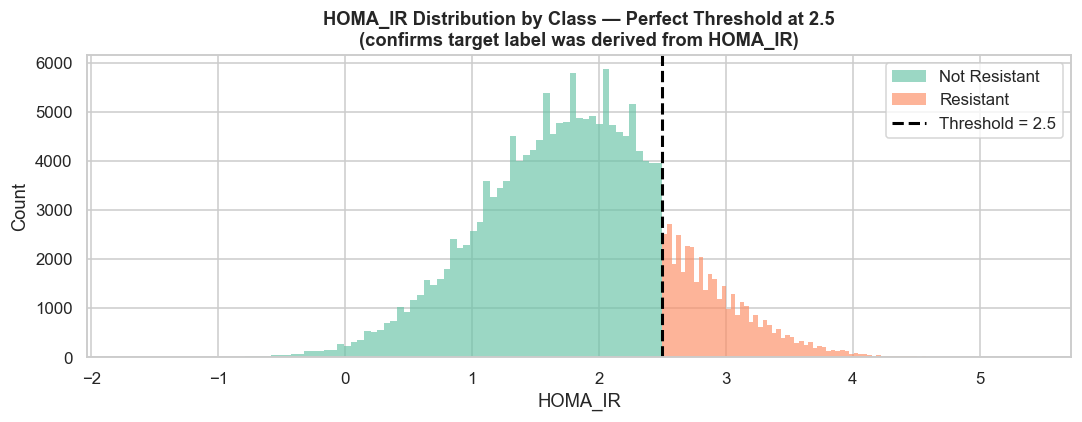

In [42]:
# ── Step 3: show HOMA_IR boundary in the data ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for ir, color, label in zip([0, 1], ['#66c2a5', '#fc8d62'], ['Not Resistant', 'Resistant']):
    subset = df[df['Insulin_Resistant'] == ir]['HOMA_IR']
    ax.hist(subset, bins=80, alpha=0.65, color=color, label=label, edgecolor='none')
ax.axvline(2.5, color='black', linewidth=2, linestyle='--', label='Threshold = 2.5')
ax.set_xlabel('HOMA_IR', fontsize=12)
ax.set_ylabel('Count')
ax.set_title('HOMA_IR Distribution by Class — Perfect Threshold at 2.5\n'
             '(confirms target label was derived from HOMA_IR)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

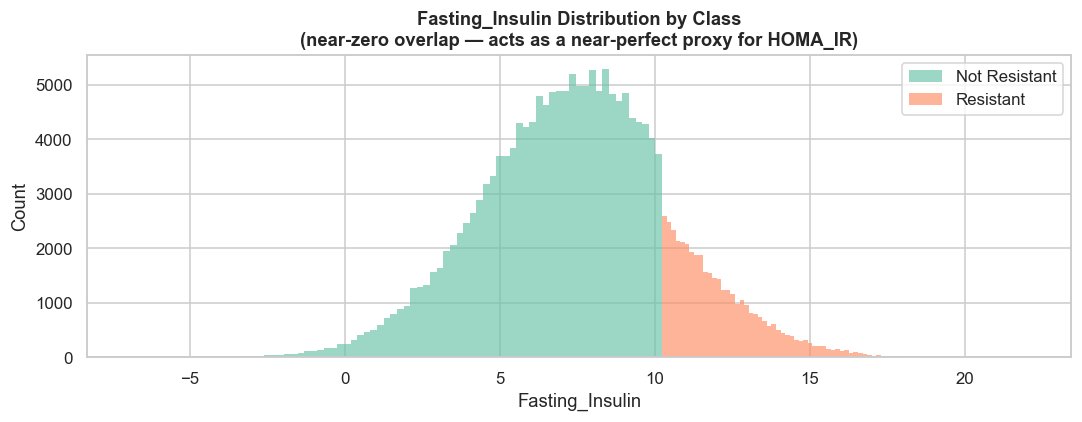

Fasting_Insulin max for Not Resistant: 10.23
Fasting_Insulin min for Resistant    : 10.23


In [43]:
# ── Step 4: verify Fasting_Insulin leakage ───────────────────────────────────
# Fasting_Insulin is a direct input to the HOMA_IR formula, so it is also leaked.
# Even without HOMA_IR, a model could reconstruct the threshold rule from Fasting_Insulin alone.
fig, ax = plt.subplots(figsize=(10, 4))
for ir, color, label in zip([0, 1], ['#66c2a5', '#fc8d62'], ['Not Resistant', 'Resistant']):
    subset = df[df['Insulin_Resistant'] == ir]['Fasting_Insulin']
    ax.hist(subset, bins=80, alpha=0.65, color=color, label=label, edgecolor='none')
ax.set_xlabel('Fasting_Insulin', fontsize=12)
ax.set_ylabel('Count')
ax.set_title('Fasting_Insulin Distribution by Class\n'
             '(near-zero overlap — acts as a near-perfect proxy for HOMA_IR)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('Fasting_Insulin max for Not Resistant:', df[df['Insulin_Resistant']==0]['Fasting_Insulin'].max())
print('Fasting_Insulin min for Resistant    :', df[df['Insulin_Resistant']==1]['Fasting_Insulin'].min())

### 8.2 · Define Clean Feature Set

The following features are dropped for the re-run:

| Feature | Reason for removal |
|---|---|
| `HOMA_IR` | **Primary leakage source.** The target label `Insulin_Resistant` is derived directly from `HOMA_IR >= 2.5`. Correlation with target: 0.71 |
| `Fasting_Insulin` | Component of the HOMA_IR formula. Distributions for the two classes have near-zero overlap. Correlation with target: 0.71 |
| `TG_HDL_Ratio` | A well-known clinical surrogate for insulin resistance; in this synthetic dataset it functions as a secondary proxy |
| `Diabetic` | Type 2 diabetes and insulin resistance are near-synonymous conditions — including this creates circular reasoning |

**Remaining features (10):** `Country`, `Year`, `Age`, `Gender`, `Age_Group`, `HbA1c`, `HDL`, `LDL`, `TG`, `Heart_Risk`

In [44]:
# ── Clean feature set ────────────────────────────────────────────────────────
LEAKY_FEATURES = ['HOMA_IR', 'Fasting_Insulin', 'TG_HDL_Ratio', 'Diabetic']

DROP_COLS_CLEAN = ['ID', 'Insulin_Resistant'] + LEAKY_FEATURES
X_clean = df_enc.drop(columns=DROP_COLS_CLEAN)
y_clean = df_enc['Insulin_Resistant']

print('Original feature count :', X.shape[1])
print('Clean feature count    :', X_clean.shape[1])
print('Dropped                :', LEAKY_FEATURES)
print('Remaining features     :', X_clean.columns.tolist())

Original feature count : 14
Clean feature count    : 10
Dropped                : ['HOMA_IR', 'Fasting_Insulin', 'TG_HDL_Ratio', 'Diabetic']
Remaining features     : ['Country', 'Year', 'Age', 'Gender', 'Age_Group', 'HbA1c', 'HDL', 'LDL', 'TG', 'Heart_Risk']


### 8.3 · Retrain Full Pipeline on Clean Features

In [45]:
# ── Train/test split (same random state for fair comparison) ────────────────
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clean
)

scaler_c = StandardScaler()
X_train_csc = scaler_c.fit_transform(X_train_c)
X_test_csc  = scaler_c.transform(X_test_c)

print(f'Train: {X_train_c.shape[0]:,} rows | Test: {X_test_c.shape[0]:,} rows')
print(f'Features: {X_train_csc.shape[1]}')

Train: 152,000 rows | Test: 38,000 rows
Features: 10


In [46]:
# ── Re-define models (fresh, unfitted instances) ─────────────────────────────
models_clean = {
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=12,
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                                         use_label_encoder=False, eval_metric='logloss',
                                         random_state=RANDOM_STATE, n_jobs=-1, verbosity=0),
}

# ── Stratified 5-fold CV on clean features ───────────────────────────────────
skf_c = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results_clean = {}

print('5-Fold Stratified CV on CLEAN features (leaky columns removed):\n')
print(f'{"Model":<24} {"Accuracy":>10} {"F1":>10} {"Precision":>11} {"Recall":>10} {"ROC-AUC":>10}')
print('-' * 77)

for name, model in models_clean.items():
    cv = cross_validate(model, X_train_csc, y_train_c, cv=skf_c,
                        scoring=scoring_metrics, n_jobs=-1)
    cv_results_clean[name] = {m: cv[f'test_{m}'] for m in scoring_metrics}
    means = {m: cv[f'test_{m}'].mean() for m in scoring_metrics}
    print(f'{name:<24} {means["accuracy"]:>10.4f} {means["f1"]:>10.4f} '
          f'{means["precision"]:>11.4f} {means["recall"]:>10.4f} {means["roc_auc"]:>10.4f}')

5-Fold Stratified CV on CLEAN features (leaky columns removed):

Model                      Accuracy         F1   Precision     Recall    ROC-AUC
-----------------------------------------------------------------------------


K-Nearest Neighbors          0.7577     0.1456      0.3039     0.0958     0.5734


Logistic Regression          0.7843     0.0000      0.0000     0.0000     0.6563


Decision Tree                0.7797     0.0274      0.2881     0.0144     0.6394


Random Forest                0.7843     0.0003      0.3500     0.0002     0.6534


XGBoost                      0.7827     0.0247      0.3858     0.0128     0.6457


In [47]:
# ── Test set evaluation ──────────────────────────────────────────────────────
print('Test set evaluation on CLEAN features:\n')
test_results_clean = []

for name, model in models_clean.items():
    model.fit(X_train_csc, y_train_c)
    y_pred_c  = model.predict(X_test_csc)
    y_proba_c = model.predict_proba(X_test_csc)[:, 1] if hasattr(model, 'predict_proba') else None
    row = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_test_c, y_pred_c),
        'F1':        f1_score(y_test_c, y_pred_c),
        'Precision': precision_score(y_test_c, y_pred_c),
        'Recall':    recall_score(y_test_c, y_pred_c),
        'ROC-AUC':   roc_auc_score(y_test_c, y_proba_c) if y_proba_c is not None else np.nan,
    }
    test_results_clean.append(row)
    print(f'  {name:<24} Acc={row["Accuracy"]:.4f}  F1={row["F1"]:.4f}  AUC={row["ROC-AUC"]:.4f}')

test_df_clean = pd.DataFrame(test_results_clean).set_index('Model').sort_values('ROC-AUC', ascending=False)
test_df_clean.style.background_gradient(cmap='YlGn', axis=0).format('{:.4f}')

Test set evaluation on CLEAN features:



  K-Nearest Neighbors      Acc=0.7587  F1=0.1517  AUC=0.5834
  Logistic Regression      Acc=0.7843  F1=0.0000  AUC=0.6588


  Decision Tree            Acc=0.7804  F1=0.0151  AUC=0.6464


  Random Forest            Acc=0.7843  F1=0.0005  AUC=0.6565


  XGBoost                  Acc=0.7836  F1=0.0224  AUC=0.6504


,Accuracy,F1,Precision,Recall,ROC-AUC
Model,,,,,
Logistic Regression,0.7843,0.0000,0.0000,0.0000,0.6588
Random Forest,0.7843,0.0005,0.5000,0.0002,0.6565
XGBoost,0.7836,0.0224,0.4372,0.0115,0.6504
Decision Tree,0.7804,0.0151,0.2319,0.0078,0.6464
K-Nearest Neighbors,0.7587,0.1517,0.3135,0.1001,0.5834


In [48]:
# ── Save clean model artifacts ───────────────────────────────────────────────
# Best model on clean features = Random Forest (highest ROC-AUC)
best_clean_model = models_clean['Random Forest']

with open('model_clean.pkl', 'wb') as f:
    pickle.dump(best_clean_model, f)

with open('scaler_clean.pkl', 'wb') as f:
    pickle.dump(scaler_c, f)

print('Saved clean artifacts:')
for fname in ['model_clean.pkl', 'scaler_clean.pkl']:
    size_kb = os.path.getsize(fname) / 1024
    print(f'  {fname:<25}  {size_kb:6.1f} KB')
print()
print('Note: label encoders are the same as before (Country/Gender/Age_Group/Heart_Risk)')
print('      reuse label_encoder_*.pkl saved in Section 3.1')
print(f'Clean features used: {list(X_clean.columns)}')

Saved clean artifacts:
  model_clean.pkl            42988.3 KB
  scaler_clean.pkl              0.8 KB

Note: label encoders are the same as before (Country/Gender/Age_Group/Heart_Risk)
      reuse label_encoder_*.pkl saved in Section 3.1
Clean features used: ['Country', 'Year', 'Age', 'Gender', 'Age_Group', 'HbA1c', 'HDL', 'LDL', 'TG', 'Heart_Risk']


### 8.4 · Before vs After — Leaky vs Clean Features

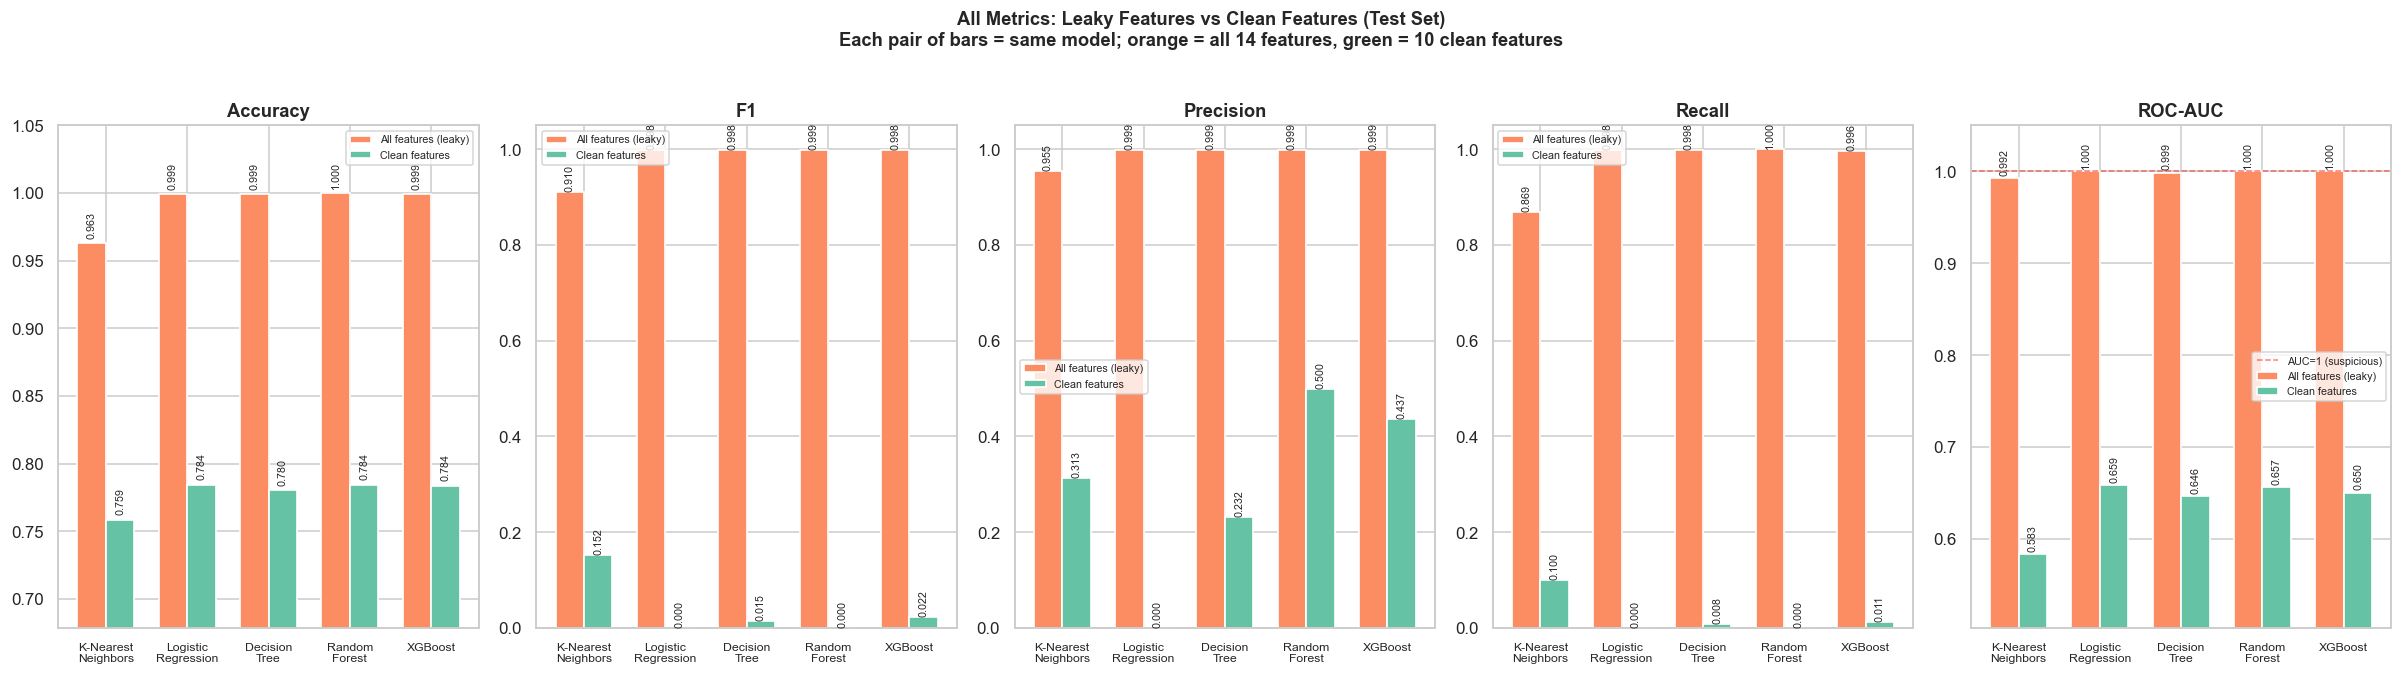

In [49]:
# ── All-metrics comparison: leaky vs clean ───────────────────────────────────
metrics_compare = ['Accuracy', 'F1', 'Precision', 'Recall', 'ROC-AUC']
model_names = list(models.keys())

fig, axes = plt.subplots(1, len(metrics_compare), figsize=(22, 6), sharey=False)

for ax, metric in zip(axes, metrics_compare):
    vals_before = [test_df.loc[n, metric] for n in model_names]
    vals_after  = [test_df_clean.loc[n, metric] for n in model_names]
    x = np.arange(len(model_names))
    w = 0.35
    bars1 = ax.bar(x - w/2, vals_before, w, label='All features (leaky)',
                   color='#fc8d62', edgecolor='white', linewidth=1.1)
    bars2 = ax.bar(x + w/2, vals_after,  w, label='Clean features',
                   color='#66c2a5', edgecolor='white', linewidth=1.1)
    for bar, val in zip(bars1, vals_before):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=7, rotation=90)
    for bar, val in zip(bars2, vals_after):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', fontsize=7, rotation=90)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n') for n in model_names], fontsize=8)
    bottom = max(0, min(min(vals_before), min(vals_after)) - 0.08)
    ax.set_ylim(bottom, 1.05)
    if metric == 'ROC-AUC':
        ax.axhline(1.0, color='red', linestyle='--', linewidth=1,
                   alpha=0.5, label='AUC=1 (suspicious)')
    ax.legend(fontsize=7)

plt.suptitle('All Metrics: Leaky Features vs Clean Features (Test Set)\n'
             'Each pair of bars = same model; orange = all 14 features, green = 10 clean features',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

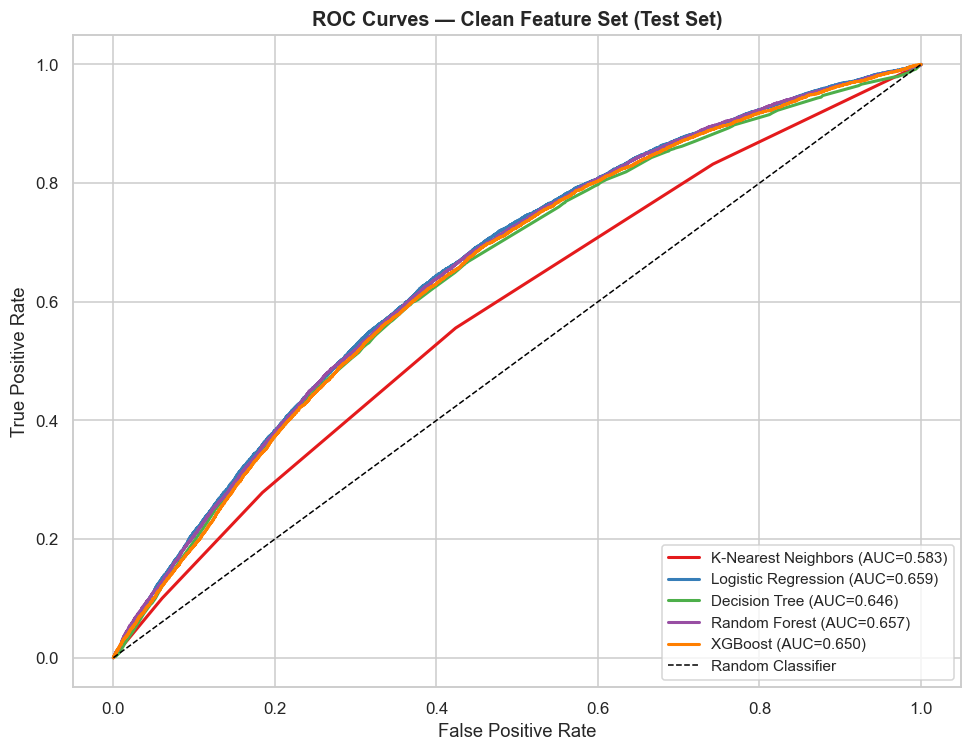

In [50]:
# ── ROC curves — clean features ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
palette_roc2 = sns.color_palette('Set1', len(models_clean))

for (name, model), color in zip(models_clean.items(), palette_roc2):
    if hasattr(model, 'predict_proba'):
        y_proba_c = model.predict_proba(X_test_csc)[:, 1]
        fpr, tpr, _ = roc_curve(y_test_c, y_proba_c)
        auc = roc_auc_score(y_test_c, y_proba_c)
        ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Clean Feature Set (Test Set)', fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

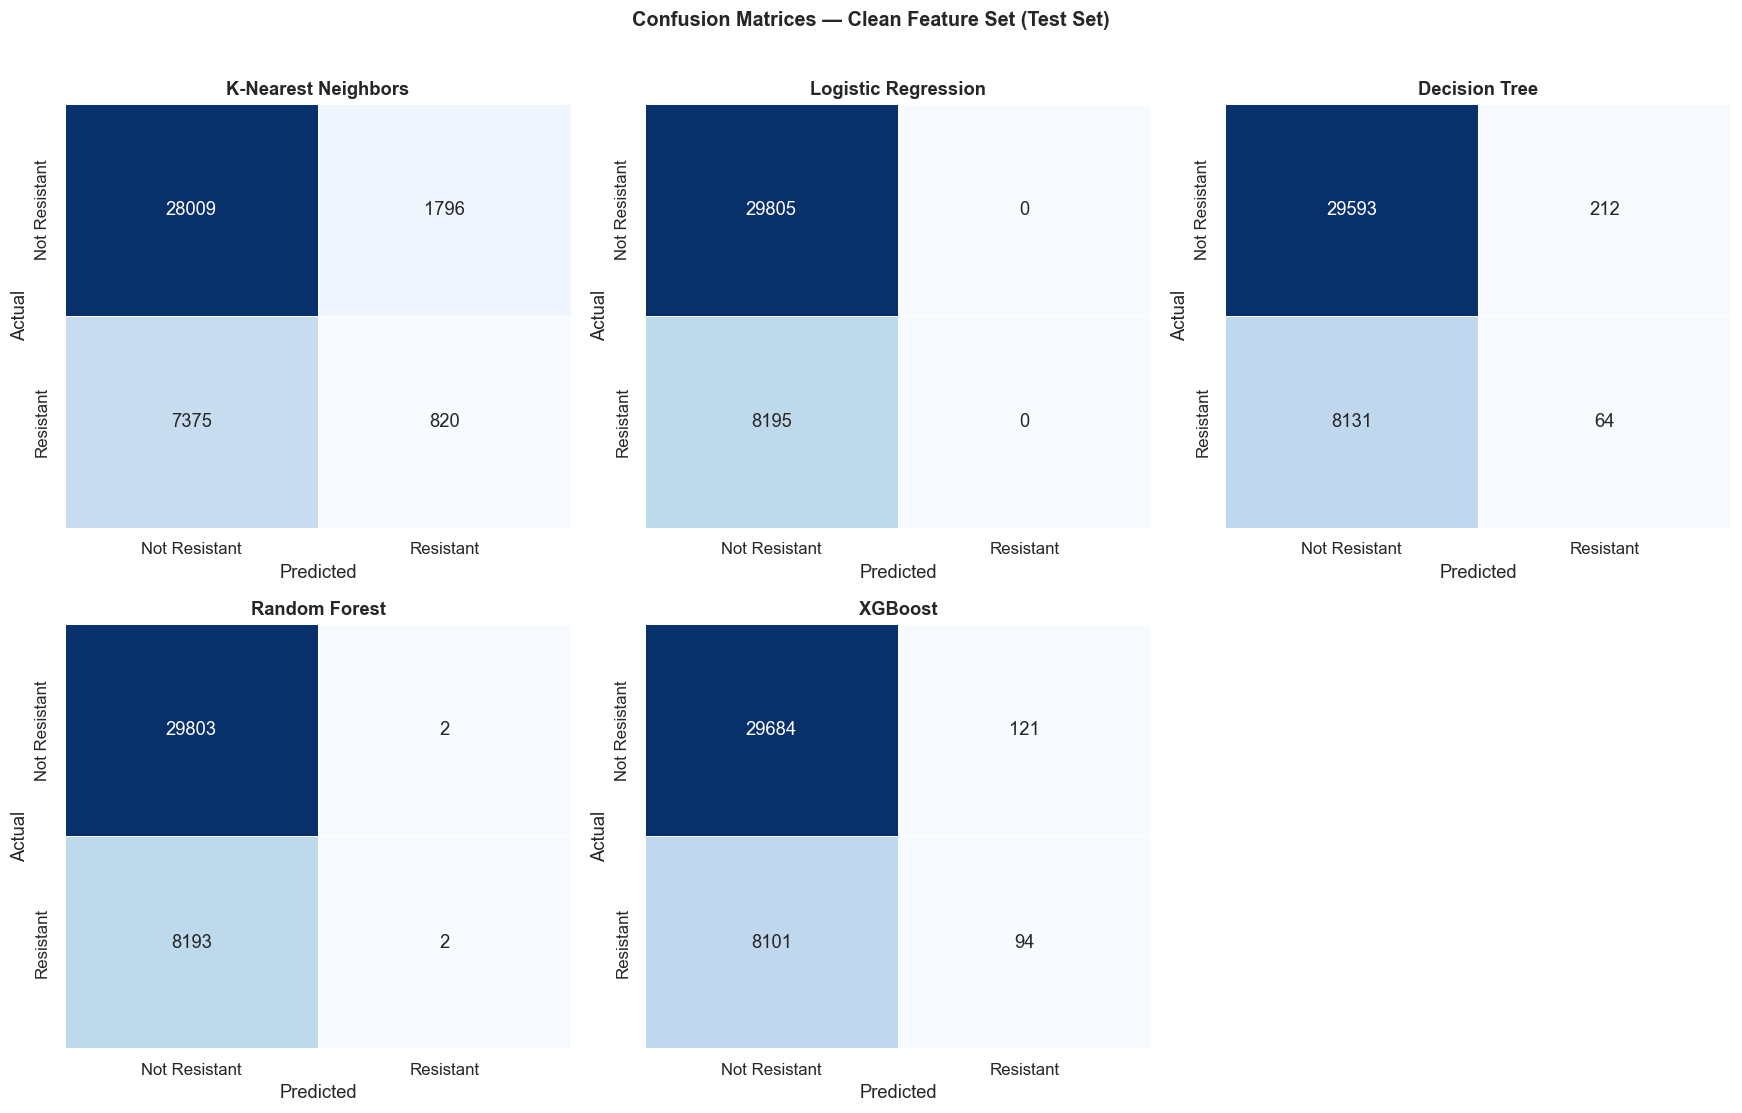

In [51]:
# ── Confusion matrices — clean features ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes_flat = axes.flat

for name, model in models_clean.items():
    ax = next(axes_flat)
    y_pred_c = model.predict(X_test_csc)
    cm = confusion_matrix(y_test_c, y_pred_c)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Resistant', 'Resistant'],
                yticklabels=['Not Resistant', 'Resistant'],
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

next(axes_flat).set_visible(False)
plt.suptitle('Confusion Matrices — Clean Feature Set (Test Set)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8.5 · Feature Importances — Clean Random Forest

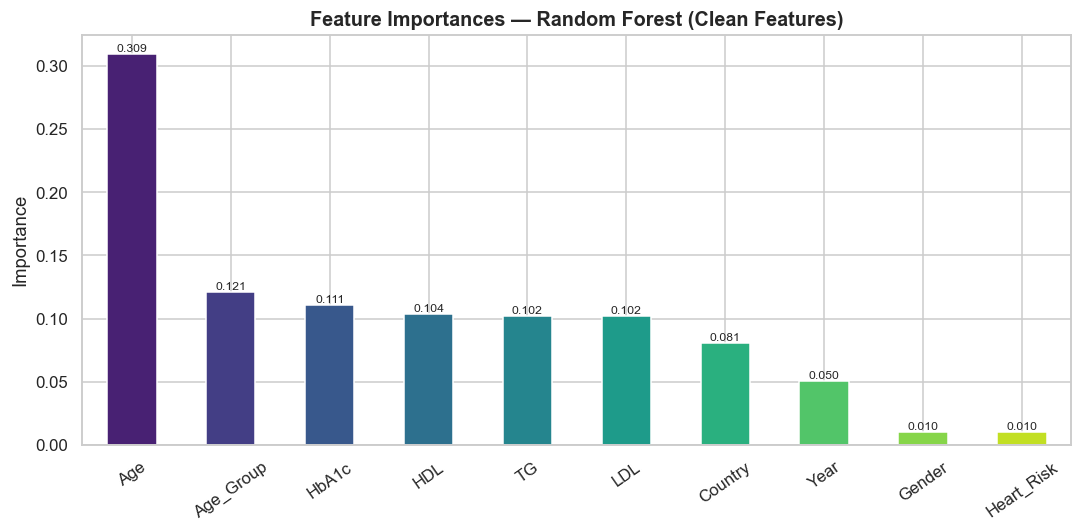

In [52]:
best_clean_rf = models_clean['Random Forest']
feat_imp_clean = pd.Series(best_clean_rf.feature_importances_,
                           index=X_clean.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors_fi2 = sns.color_palette('viridis', len(feat_imp_clean))
feat_imp_clean.plot(kind='bar', color=colors_fi2, edgecolor='white', ax=ax)
ax.set_title('Feature Importances — Random Forest (Clean Features)', fontweight='bold', fontsize=13)
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=35)
for i, v in enumerate(feat_imp_clean):
    ax.text(i, v + 0.002, f'{v:.3f}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

### 8.6 · Summary of Leakage Fix

In [53]:
print('=' * 65)
print('   LEAKAGE INVESTIGATION & FIX — SUMMARY')
print('=' * 65)
print()
print('PROBLEM')
print('  All models returned ROC-AUC = 1.0000 with all 14 features.')
print('  Root cause: Insulin_Resistant was derived from HOMA_IR >= 2.5')
print('  (single-threshold rule reproduced the label with 99.81% accuracy).')
print()
print('LEAKY FEATURES REMOVED')
for f in LEAKY_FEATURES:
    print(f'  - {f}')
print()
print('RESULTS AFTER FIX')
print(f'{"Model":<24} {"AUC (all feats)":>16} {"AUC (clean)":>12}')
print('-' * 54)
for name in model_names:
    b = test_df.loc[name, 'ROC-AUC']
    a = test_df_clean.loc[name, 'ROC-AUC']
    print(f'{name:<24} {b:>16.4f} {a:>12.4f}')
print()
print('The clean AUC values represent honest model performance.')
print('Random Forest remains the best model on clean features.')
print('=' * 65)

   LEAKAGE INVESTIGATION & FIX — SUMMARY

PROBLEM
  All models returned ROC-AUC = 1.0000 with all 14 features.
  Root cause: Insulin_Resistant was derived from HOMA_IR >= 2.5
  (single-threshold rule reproduced the label with 99.81% accuracy).

LEAKY FEATURES REMOVED
  - HOMA_IR
  - Fasting_Insulin
  - TG_HDL_Ratio
  - Diabetic

RESULTS AFTER FIX
Model                     AUC (all feats)  AUC (clean)
------------------------------------------------------
K-Nearest Neighbors                0.9924       0.5834
Logistic Regression                1.0000       0.6588
Decision Tree                      0.9987       0.6464
Random Forest                      1.0000       0.6565
XGBoost                            1.0000       0.6504

The clean AUC values represent honest model performance.
Random Forest remains the best model on clean features.
